# Intro

In [23]:
# Import required libs

import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
import warnings
import time

from scipy.linalg import eigh
from scipy.ndimage import median_filter, uniform_filter
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from skimage.feature import local_binary_pattern
from skimage.filters import gaussian, sobel
from skimage.filters.rank import entropy
from skimage.morphology import disk

In [24]:
%pip install tabulate
%pip install torch torchvision


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /Users/Maksym_Rybnytskyi/Library/CloudStorage/OneDrive-EPAM/Університет/Аспірантура/PhD/Repositories/xgboost-classifiers/my_env_name/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /Users/Maksym_Rybnytskyi/Library/CloudStorage/OneDrive-EPAM/Університет/Аспірантура/PhD/Repositories/xgboost-classifiers/my_env_name/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
# Load data
def load_pavia_data(data_path, gt_path):
    """Loads data and mask from .mat files."""
    data = sio.loadmat(data_path)['paviaU']
    gt = sio.loadmat(gt_path)['paviaU_gt']
    return data, gt

In [26]:
# Get RGB
def get_rgb_image(data, bands=(55, 30, 10)):
    """
    Creates an RGB image based on the selected bands.
    bands: tuple of (Red, Green, Blue) band indices.
    """
    # Select bands
    rgb = data[:, :, bands].astype(np.float32)
    
    # Normalization (Min-Max Scaling) for proper visualization
    for i in range(3):
        min_val = rgb[:,:,i].min()
        max_val = rgb[:,:,i].max()
        if max_val - min_val > 0:
            rgb[:,:,i] = (rgb[:,:,i] - min_val) / (max_val - min_val)
            
    return rgb

In [27]:
# Visualize dataset
def visualize_pavia(data, gt, rgb_bands=(55, 30, 10)):
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # 1. Pseudo-RGB visualization
    rgb_img = get_rgb_image(data, rgb_bands)
    ax[0].imshow(rgb_img)
    ax[0].set_title(f'Pseudo-RGB (Bands: {rgb_bands})')
    ax[0].axis('off')

    # 2. Updated palette (FIRST COLOR IS WHITE)
    class_colors = [
        '#FFFFFF', # 0: Undefined -> NOW WHITE
        '#D8BFD8', # 1: Asphalt
        '#00FF00', # 2: Meadow
        '#00FFFF', # 3: Gravel
        '#006400', # 4: Trees
        '#FF00FF', # 5: Metal sheets
        '#FF8C00', # 6: Bare soil
        '#9400D3', # 7: Bitumen
        '#FF0000', # 8: Bricks
        '#FFFF00'  # 9: Shadows
    ]
    
    cmap = ListedColormap(class_colors)
    
    # Display the mask
    im = ax[1].imshow(gt, cmap=cmap)
    ax[1].set_title('Ground Truth (White Background)')
    ax[1].axis('off')
    
    # 3. Legend
    class_names = [
        'Undefined', 'Asphalt', 'Meadow', 'Gravel', 'Trees', 
        'Metal sheets', 'Bare soil', 'Bitumen', 'Bricks', 'Shadows'
    ]
    
    cb = plt.colorbar(im, ax=ax[1], ticks=range(10), fraction=0.046, pad=0.04)
    cb.ax.set_yticklabels(class_names)

    plt.tight_layout()
    plt.show()    

In [28]:
# Compare pixels power
def plot_spectral_signature(data, gt, pixel_coords):
    """
    Displays the spectral profile of a specific pixel.
    pixel_coords: list of tuples (y, x)
    """
    plt.figure(figsize=(10, 5))
    for y, x in pixel_coords:
        label = f"Pixel ({y},{x}) - Class {gt[y, x]}"
        plt.plot(data[y, x, :], label=label)
    
    plt.title("Pixel Spectral Profiles")
    plt.xlabel("Band Number")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
# 1. Check data type (bit depth)
# 1. Loading
cube_data, gt = load_pavia_data('dataset/PaviaU.mat', 'dataset/PaviaU_gt.mat')
print("Dataset data type:", cube_data.dtype)

# 2. Check Pepper value (minimum)
print("Pepper value (Global minimum):", np.min(cube_data))

# 3. Check Salt value (maximum)
print("Salt value (Global maximum):", np.max(cube_data))

Dataset data type: uint16
Pepper value (Global minimum): 0
Salt value (Global maximum): 8000


In [30]:
# Add S&P noise
def add_sp_noise_cube(cube_data, noise_ratio=0.05):
    """
    Adds impulse noise (Salt & Pepper) to the hyperspectral cube (all bands).
    Simulates data packet loss or hardware failures.
    """
    print(f"[*] Generating Salt & Pepper noise (Intensity: {noise_ratio * 100}%)...")
    noisy_cube = np.copy(cube_data)
    
    # Determine global minimum and maximum for the dataset
    val_min = np.min(cube_data)
    val_max = np.max(cube_data)
    
    # Create a matrix of random probabilities from 0 to 1
    random_matrix = np.random.rand(*cube_data.shape)
    
    # Pepper (Black pixels) - half of the given noise
    noisy_cube[random_matrix < (noise_ratio / 2.0)] = val_min
    
    # Salt (White pixels) - the other half
    noisy_cube[(random_matrix >= (noise_ratio / 2.0)) & (random_matrix < noise_ratio)] = val_max
    
    return noisy_cube

In [31]:
# Calculate MNF (Additioanal investigation of behavior)
def perform_mnf(cube_data, n_components=15):
    """
    Performs MNF transformation with regularization for robustness against impulse noise.
    """
    h, w, b = cube_data.shape
    cube_2d = cube_data.reshape(h * w, b)
    
    print("[*] 1/4: Estimating noise covariance matrix...")
    noise_diff = cube_data[:, :-1, :] - cube_data[:, 1:, :]
    noise_2d = noise_diff.reshape(-1, b)
    cov_noise = np.cov(noise_2d, rowvar=False)
    
    # FIX 1: Noise matrix regularization (stabilization)
    cov_noise = cov_noise + np.eye(b) * 1e-5
    
    print("[*] 2/4: Estimating data covariance matrix...")
    cov_data = np.cov(cube_2d, rowvar=False)
    
    print("[*] 3/4: Solving the generalized eigenvalue problem...")
    eigenvalues, eigenvectors = eigh(cov_data, cov_noise)
    
    print(f"[*] 4/4: Sorting and projection onto {n_components} components...")
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    
    w_reduce = eigenvectors[:, :n_components]
    reduced_2d = np.dot(cube_2d, w_reduce)
    
    return reduced_2d.reshape(h, w, n_components)

In [32]:
# def extract_teg_v_matrix(cube, gt_mask): (Next investigation)
#     """
#     Екстрагує Multi-Scale TEG-V (Texture-Entropy-Gradient-Variance) ознаки.
#     1. Median Preprocessing (3x3)
#     2. Multi-Scale Sobel (sigma=0, 1, 3)
#     3. Multi-Scale Entropy (disk 3, 5, 7)
#     4. Multi-Scale LBP (radii 1, 2, 3)
#     5. Multi-Scale Variance (window 5x5, 7x7)
#     """
#     print("[*] Початок екстракції Multi-Scale TEG-V ознак...")
#     rgb = get_rgb_image(cube)
#     h, w, _ = rgb.shape
#     features = [rgb] # Базові RGB канали
    
#     lbp_configs = [(1, 8), (2, 16), (3, 24)]
#     entropy_radii = [3, 5, 7]
#     sobel_sigmas = [0, 1, 3]
#     variance_windows = [5, 7]

#     for ch_idx in range(3):
#         ch_raw = rgb[:, :, ch_idx]
        
#         # 1. Median Preprocessing
#         ch = median_filter(ch_raw, size=3)
        
#         # 2. Multi-Scale Sobel
#         for sigma in sobel_sigmas:
#             ch_input = gaussian(ch, sigma=sigma) if sigma > 0 else ch
#             grad = sobel(ch_input)
#             features.append(grad[:, :, np.newaxis])

#         # 3. Multi-Scale Entropy
#         ch_8bit = (ch * 255).astype(np.uint8)
#         for r in entropy_radii:
#             ent = entropy(ch_8bit, disk(r))
#             features.append(ent[:, :, np.newaxis])

#         # 4. Multi-Scale LBP
#         for r, p in lbp_configs:
#             lbp_map = local_binary_pattern(ch, p, r, method='uniform')
#             lbp_norm = lbp_map / (lbp_map.max() + 1e-6)
#             features.append(lbp_norm[:, :, np.newaxis])

#         # 5. Multi-Scale Variance (Fast implementation using uniform_filter)
#         for win in variance_windows:
#             mean = uniform_filter(ch, size=win)
#             sq_mean = uniform_filter(ch**2, size=win)
#             var = np.maximum(sq_mean - mean**2, 0) # Чисельна стабільність
#             features.append(var[:, :, np.newaxis])

#     teg_cube = np.concatenate(features, axis=2)
#     print(f"[+] Екстракцію завершено. Кількість ознак на піксель: {teg_cube.shape[2]}")

#     # Векторизація та фільтрація за маскою
#     valid_mask = (gt_mask != 0)
#     X_flat = teg_cube.reshape(h * w, -1)[valid_mask.flatten()]
    
#     return StandardScaler().fit_transform(X_flat)

In [33]:
def evaluate_learning_curve(X, y, train_fractions, test_size=0.2, random_state=42):
    """Updated function: now also measures training time for each data portion"""
    X_train_pool, X_test, y_train_pool, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    total_samples = len(y)
    f1_scores = []
    accuracy_scores = []
    train_times = [] # NEW ARRAY FOR TIME
    
    for frac in train_fractions:
        n_train_samples = int(total_samples * frac)
        n_train_samples = min(n_train_samples, len(y_train_pool))
        
        if n_train_samples < len(y_train_pool):
            X_train, _, y_train, _ = train_test_split(
                X_train_pool, y_train_pool, train_size=n_train_samples, 
                stratify=y_train_pool, random_state=random_state
            )
        else:
            X_train, y_train = X_train_pool, y_train_pool
            
        clf = xgb.XGBClassifier(
            objective='multi:softmax', n_estimators=200, max_depth=8, eta=0.3,
            eval_metric='mlogloss', tree_method='hist', n_jobs=-1, random_state=random_state
        )
        
        # Measure only the execution time of .fit()
        t0 = time.time()
        clf.fit(X_train, y_train)
        train_times.append(time.time() - t0)
        
        y_pred = clf.predict(X_test)
        
        f1_scores.append(f1_score(y_test, y_pred, average='macro'))
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        
    return f1_scores, accuracy_scores, train_times # NOW RETURNS 3 VALUES

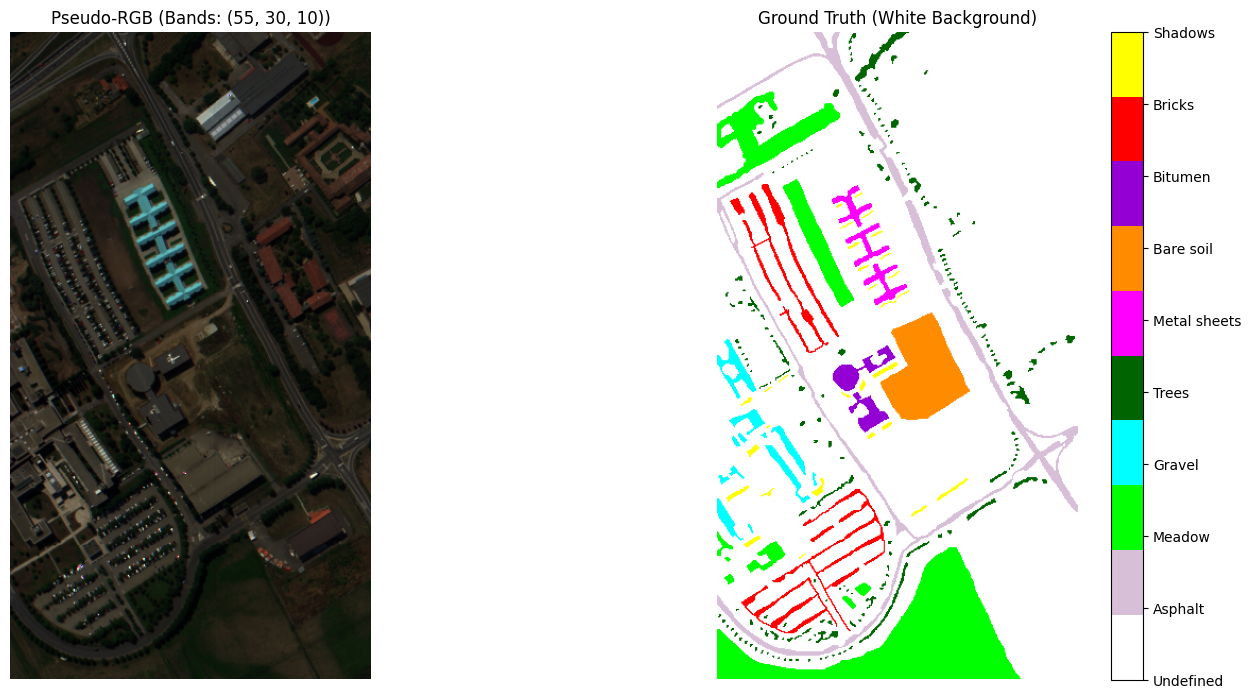

[*] Generating Salt & Pepper noise (Intensity: 1.0%)...
[*] Generating Salt & Pepper noise (Intensity: 5.0%)...
[*] Generating Salt & Pepper noise (Intensity: 10.0%)...
[*] Generating Salt & Pepper noise (Intensity: 20.0%)...
[+] All noisy datasets successfully generated!


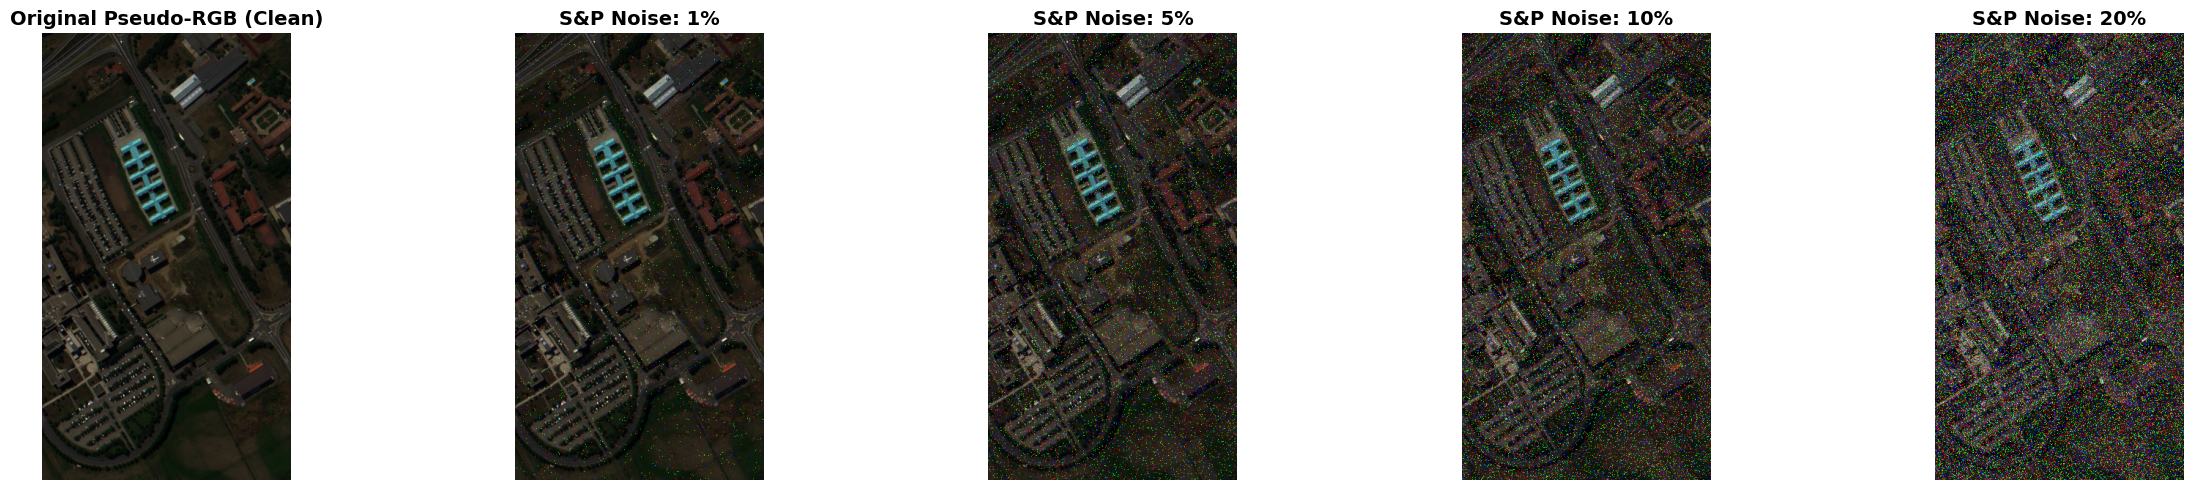

In [34]:
# =============================================================================
# MAIN PIPELINE
# =============================================================================
"""
Main Execution Pipeline: Impact of Impulse Noise on Pavia University Dataset

This section executes the primary workflow for evaluating the robustness 
of hyperspectral image classification against impulse (Salt & Pepper) noise. 
It loads the ground truth and spectral data, establishes a clean baseline, 
and systematically generates progressively degraded data cubes at predefined 
stress-test levels. Finally, it constructs a comparative visualization of 
pseudo-RGB composites to visually assess the progressive signal degradation.
"""
# 1. Loading
data, gt = load_pavia_data('dataset/PaviaU.mat', 'dataset/PaviaU_gt.mat')

# 2. General visualization
visualize_pavia(data, gt)

# 4. Define stress-testing levels: 1%, 5%, 10%, 20%
noise_levels = [0.01, 0.05, 0.10, 0.20]
noisy_datasets = {}

# 5. Generate noisy hyperspectral cubes for each level
for nl in noise_levels:
    noisy_datasets[nl] = add_sp_noise_cube(data, noise_ratio=nl)
print("[+] All noisy datasets successfully generated!")

# 6. Comprehensive degradation visualization (RGB composites)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Base image (Original)
axes[0].imshow(get_rgb_image(data))
axes[0].set_title('Original Pseudo-RGB (Clean)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Noisy images
for i, nl in enumerate(noise_levels):
    ax = axes[i + 1]
    ax.imshow(get_rgb_image(noisy_datasets[nl]))
    ax.set_title(f'S&P Noise: {int(nl*100)}%', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

[*] 1. Preparing clean data (Original 103 channels)...
[*] 2. Performing PCA (103 -> 15) on clean data...
[*] 3. Performing MNF (103 -> 15) on clean data...
[*] 1/4: Estimating noise covariance matrix...
[*] 2/4: Estimating data covariance matrix...
[*] 3/4: Solving the generalized eigenvalue problem...
[*] 4/4: Sorting and projection onto 15 components...

[*] Starting XGBoost training on clean data (this will take a little longer)...
    Training: Clean: All 103 Channels...
    Training: Clean: PCA (15 comp)...
    Training: Clean: MNF (15 comp)...
[+] Training completed!


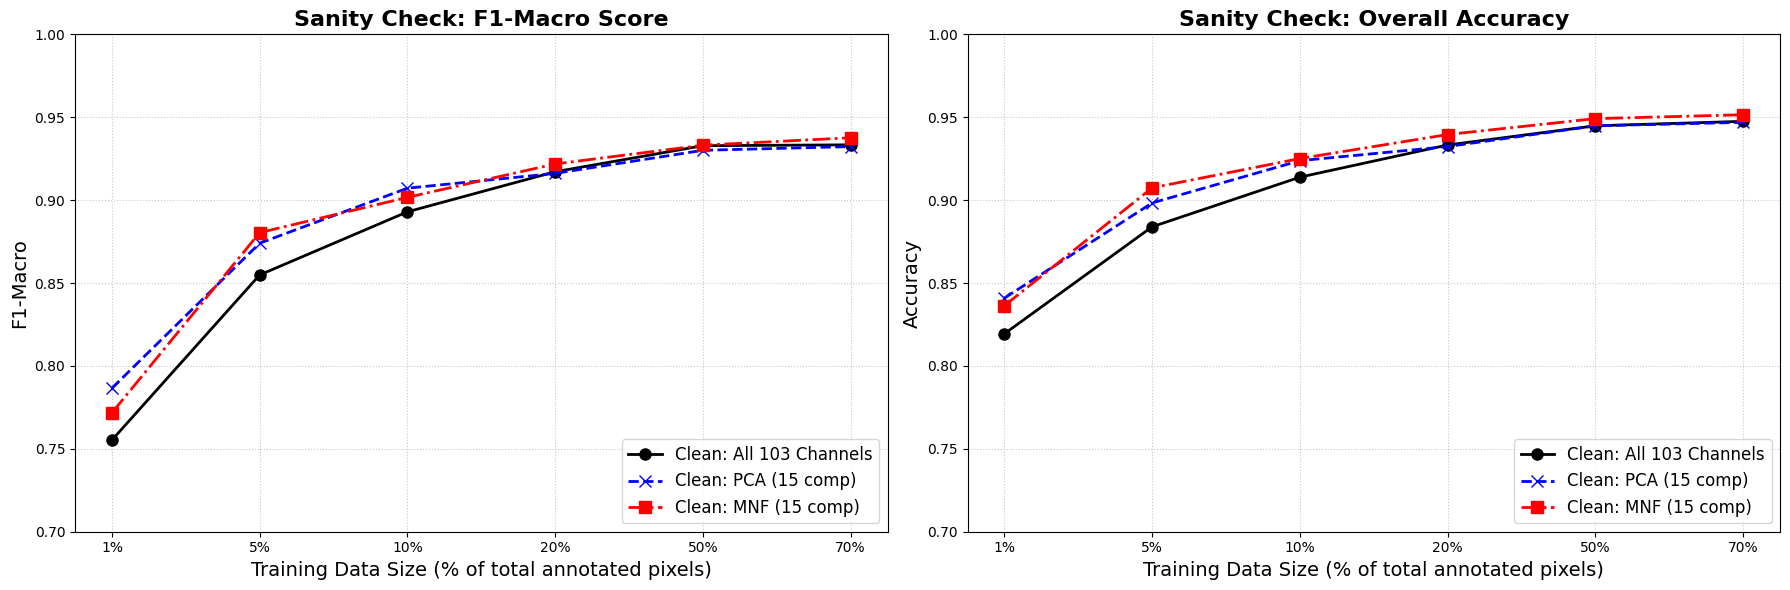


=== RESULTS TABLE: F1-MACRO ===
Train Size                   1%      5%     10%     20%     50%     70%
Clean: All 103 Channels  0.7553  0.8549  0.8929  0.9171  0.9328  0.9334
Clean: PCA (15 comp)     0.7866  0.8740  0.9072  0.9161  0.9300  0.9323
Clean: MNF (15 comp)     0.7718  0.8804  0.9017  0.9218  0.9331  0.9376

=== RESULTS TABLE: OVERALL ACCURACY ===
Train Size                   1%      5%     10%     20%     50%     70%
Clean: All 103 Channels  0.8194  0.8839  0.9139  0.9333  0.9448  0.9475
Clean: PCA (15 comp)     0.8409  0.8983  0.9238  0.9323  0.9448  0.9469
Clean: MNF (15 comp)     0.8364  0.9074  0.9251  0.9396  0.9492  0.9515


In [37]:
# =============================================================================
# MAIN 2: SANITY CHECK - Training on CLEAN data (No noise)
# =============================================================================
"""
Note: This section was conducted as an additional study to verify 
how the XGBoost classifier performs under conditions of spatial 
compression (dimensionality reduction via PCA and MNF).
"""
print("[*] 1. Preparing clean data (Original 103 channels)...")
valid_mask = (gt != 0)
h, w = gt.shape
gt_flat = gt.flatten()
y = gt_flat[valid_mask.flatten()] - 1 

scaler = StandardScaler()

cube_clean_2d = data.reshape(h * w, -1)
X_clean_103 = scaler.fit_transform(cube_clean_2d[valid_mask.flatten()])

print("[*] 2. Performing PCA (103 -> 15) on clean data...")
pca = PCA(n_components=15)
reduced_pca_2d = pca.fit_transform(cube_clean_2d)
X_clean_pca = scaler.fit_transform(reduced_pca_2d[valid_mask.flatten()])

print("[*] 3. Performing MNF (103 -> 15) on clean data...")
reduced_mnf_cube = perform_mnf(data, n_components=15)
reduced_mnf_2d = reduced_mnf_cube.reshape(h * w, -1)
X_clean_mnf = scaler.fit_transform(reduced_mnf_2d[valid_mask.flatten()])

# =============================================================================
# TRAINING (CLEAN DATA)
# =============================================================================
train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]

models_to_test_clean = {
    "Clean: All 103 Channels": X_clean_103,
    "Clean: PCA (15 comp)": X_clean_pca,
    "Clean: MNF (15 comp)": X_clean_mnf
}

# Store results separately
results_f1 = {}
results_acc = {}

print("\n[*] Starting XGBoost training on clean data (this will take a little longer)...")
for model_name, X_data in models_to_test_clean.items():
    print(f"    Training: {model_name}...")
    # Unpack the values
    f1_list, acc_list, time_list = evaluate_learning_curve(X_data, y, train_fractions, test_size=0.2)
    results_f1[model_name] = f1_list
    results_acc[model_name] = acc_list

print("[+] Training completed!")

# =============================================================================
# VISUALIZATION (TWO PLOTS) AND TABLES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

styles_clean = {
    "Clean: All 103 Channels": {"color": "black", "linestyle": "-", "marker": "o"},
    "Clean: PCA (15 comp)": {"color": "blue", "linestyle": "--", "marker": "x"},
    "Clean: MNF (15 comp)": {"color": "red", "linestyle": "-.", "marker": "s"}
}

# Plot 1: F1-Macro
for model_name, scores in results_f1.items():
    s = styles_clean[model_name]
    axes[0].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[0].set_title("Sanity Check: F1-Macro Score", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[0].set_ylabel("F1-Macro", fontsize=14)
axes[0].set_ylim(0.7, 1.0) 
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower right', fontsize=12)

# Plot 2: Overall Accuracy
for model_name, scores in results_acc.items():
    s = styles_clean[model_name]
    axes[1].plot(fraction_labels, scores, label=model_name, 
                 color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)

axes[1].set_title("Sanity Check: Overall Accuracy", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
axes[1].set_ylabel("Accuracy", fontsize=14)
axes[1].set_ylim(0.7, 1.0) 
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

df_f1 = pd.DataFrame(results_f1, index=fraction_labels).T
df_f1.columns.name = "Train Size"

df_acc = pd.DataFrame(results_acc, index=fraction_labels).T
df_acc.columns.name = "Train Size"

print("\n=== RESULTS TABLE: F1-MACRO ===")
print(df_f1.round(4))

print("\n=== RESULTS TABLE: OVERALL ACCURACY ===")
print(df_acc.round(4))

[*] 1. Initializing global experiment...

[*] EXPERIMENT: 0% Noise (Clean)
  -> Preparing All 103 Channels...
  -> Performing PCA (103 -> 15)...
  -> Performing MNF (103 -> 15)...
[*] 1/4: Estimating noise covariance matrix...
[*] 2/4: Estimating data covariance matrix...
[*] 3/4: Solving the generalized eigenvalue problem...
[*] 4/4: Sorting and projection onto 15 components...

  [*] Training XGBoost models for 0% Noise (Clean)...
      Training: All 103 Channels...
      Training: PCA (15 comp)...
      Training: MNF (15 comp)...

[*] EXPERIMENT: 1% Noise
  -> Preparing All 103 Channels...
  -> Performing PCA (103 -> 15)...
  -> Performing MNF (103 -> 15)...
[*] 1/4: Estimating noise covariance matrix...
[*] 2/4: Estimating data covariance matrix...
[*] 3/4: Solving the generalized eigenvalue problem...
[*] 4/4: Sorting and projection onto 15 components...

  [*] Training XGBoost models for 1% Noise...
      Training: All 103 Channels...
      Training: PCA (15 comp)...
      Traini

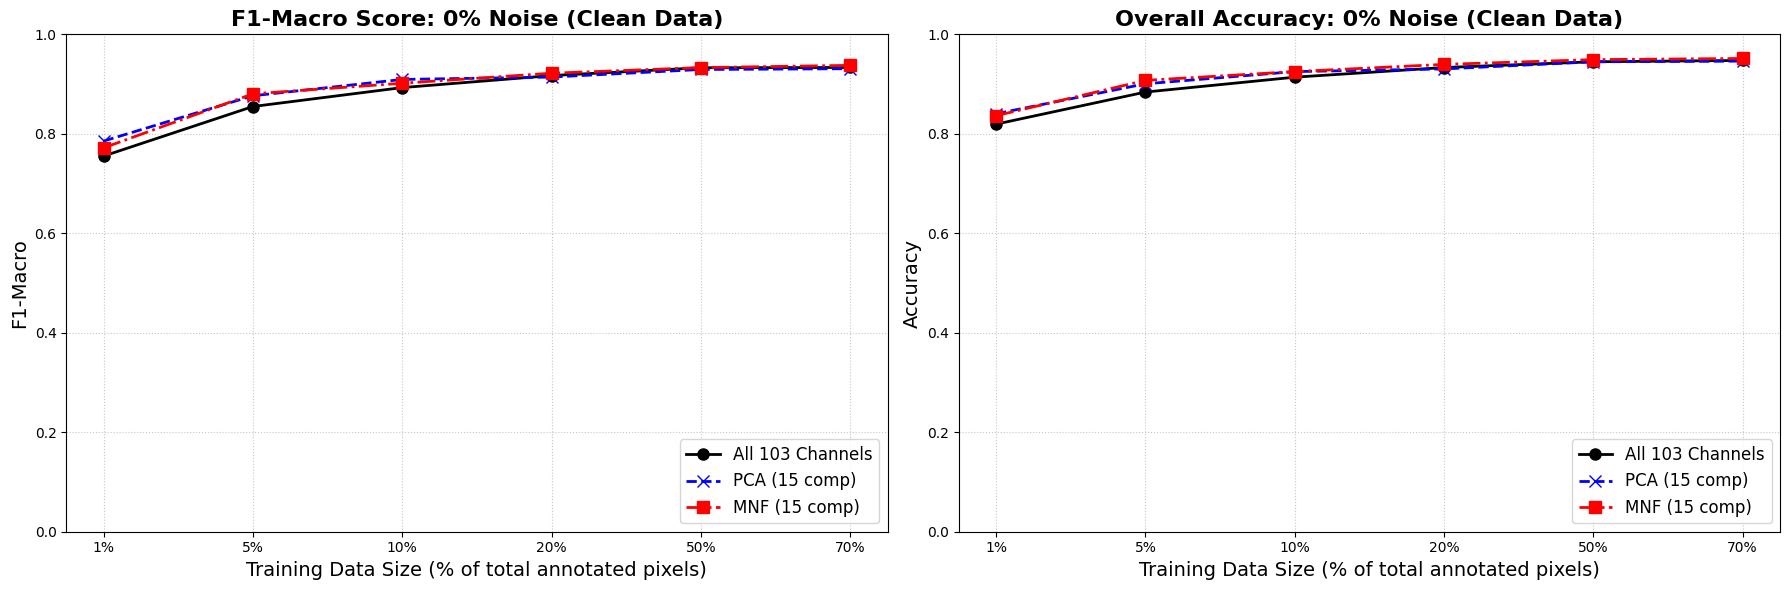


=== RESULTS TABLE: F1-MACRO (0% Noise (Clean Data)) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7553  0.8549  0.8929  0.9171  0.9328  0.9334
PCA (15 comp)     0.7854  0.8765  0.9094  0.9141  0.9293  0.9309
MNF (15 comp)     0.7718  0.8804  0.9017  0.9218  0.9331  0.9376

=== RESULTS TABLE: OVERALL ACCURACY (0% Noise (Clean Data)) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.8194  0.8839  0.9139  0.9333  0.9448  0.9475
PCA (15 comp)     0.8403  0.9005  0.9251  0.9305  0.9448  0.9461
MNF (15 comp)     0.8364  0.9074  0.9251  0.9396  0.9492  0.9515

▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



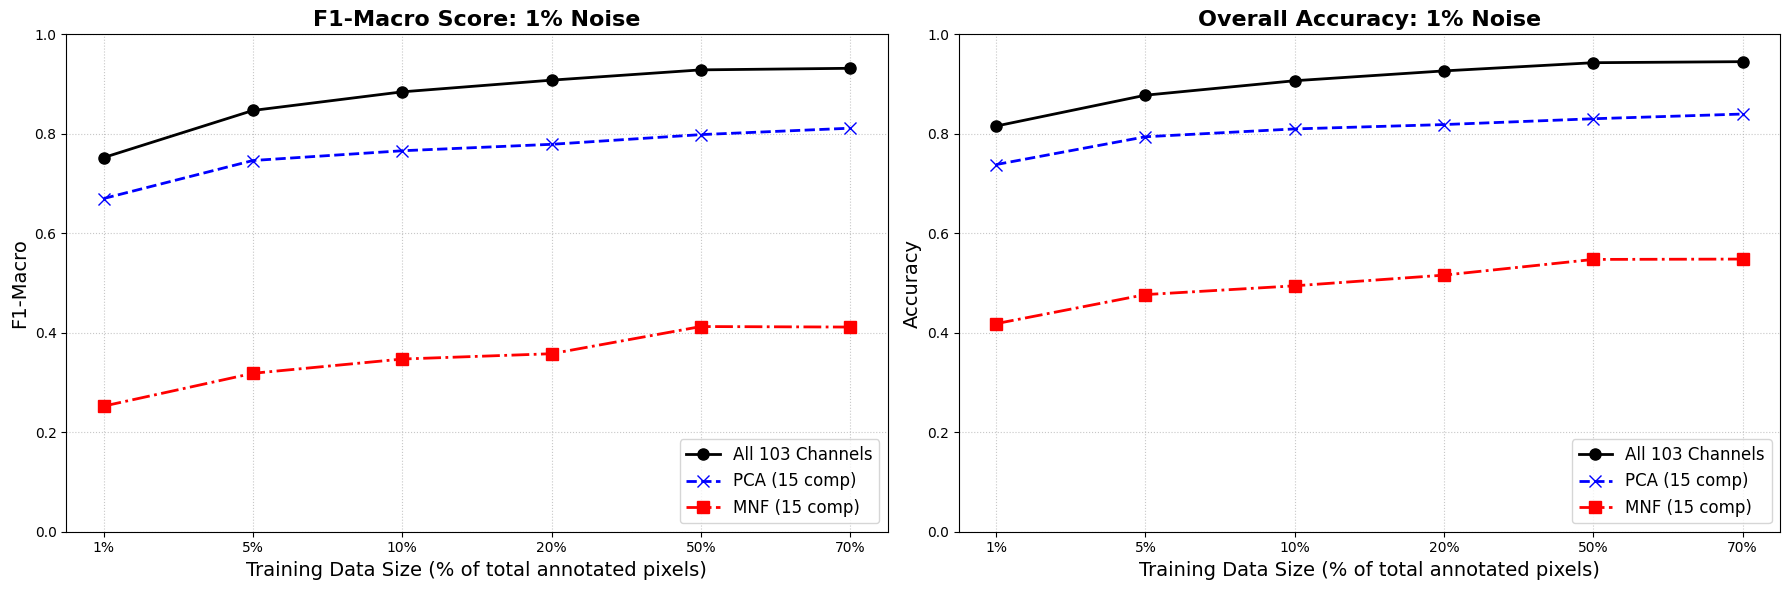


=== RESULTS TABLE: F1-MACRO (1% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7522  0.8470  0.8844  0.9079  0.9286  0.9317
PCA (15 comp)     0.6699  0.7463  0.7659  0.7789  0.7984  0.8113
MNF (15 comp)     0.2525  0.3185  0.3472  0.3579  0.4125  0.4115

=== RESULTS TABLE: OVERALL ACCURACY (1% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.8156  0.8776  0.9067  0.9265  0.9430  0.9451
PCA (15 comp)     0.7382  0.7941  0.8098  0.8186  0.8303  0.8398
MNF (15 comp)     0.4183  0.4767  0.4944  0.5159  0.5475  0.5482

▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



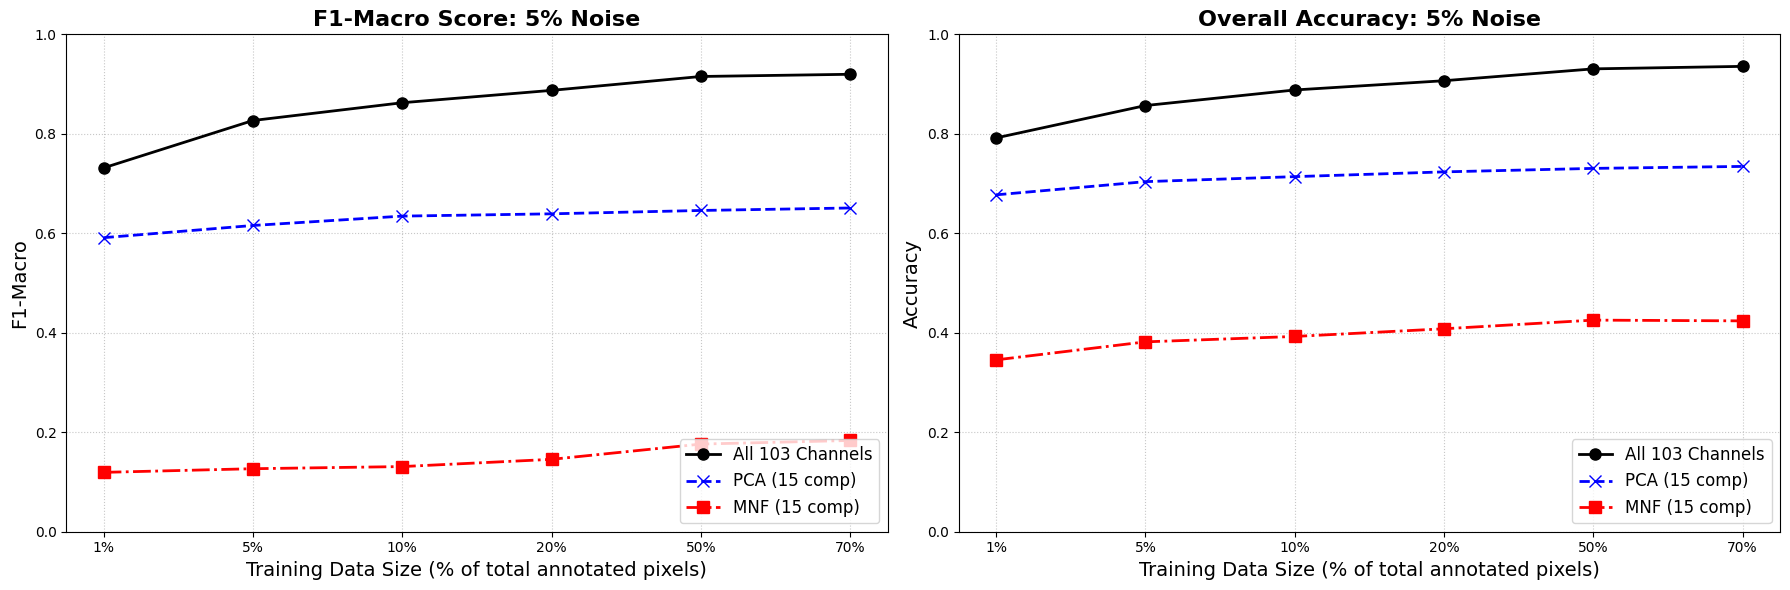


=== RESULTS TABLE: F1-MACRO (5% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7315  0.8267  0.8625  0.8873  0.9153  0.9197
PCA (15 comp)     0.5912  0.6157  0.6345  0.6391  0.6459  0.6509
MNF (15 comp)     0.1193  0.1267  0.1310  0.1455  0.1762  0.1835

=== RESULTS TABLE: OVERALL ACCURACY (5% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7917  0.8568  0.8881  0.9067  0.9306  0.9356
PCA (15 comp)     0.6773  0.7038  0.7139  0.7235  0.7305  0.7345
MNF (15 comp)     0.3455  0.3817  0.3926  0.4080  0.4254  0.4239

▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



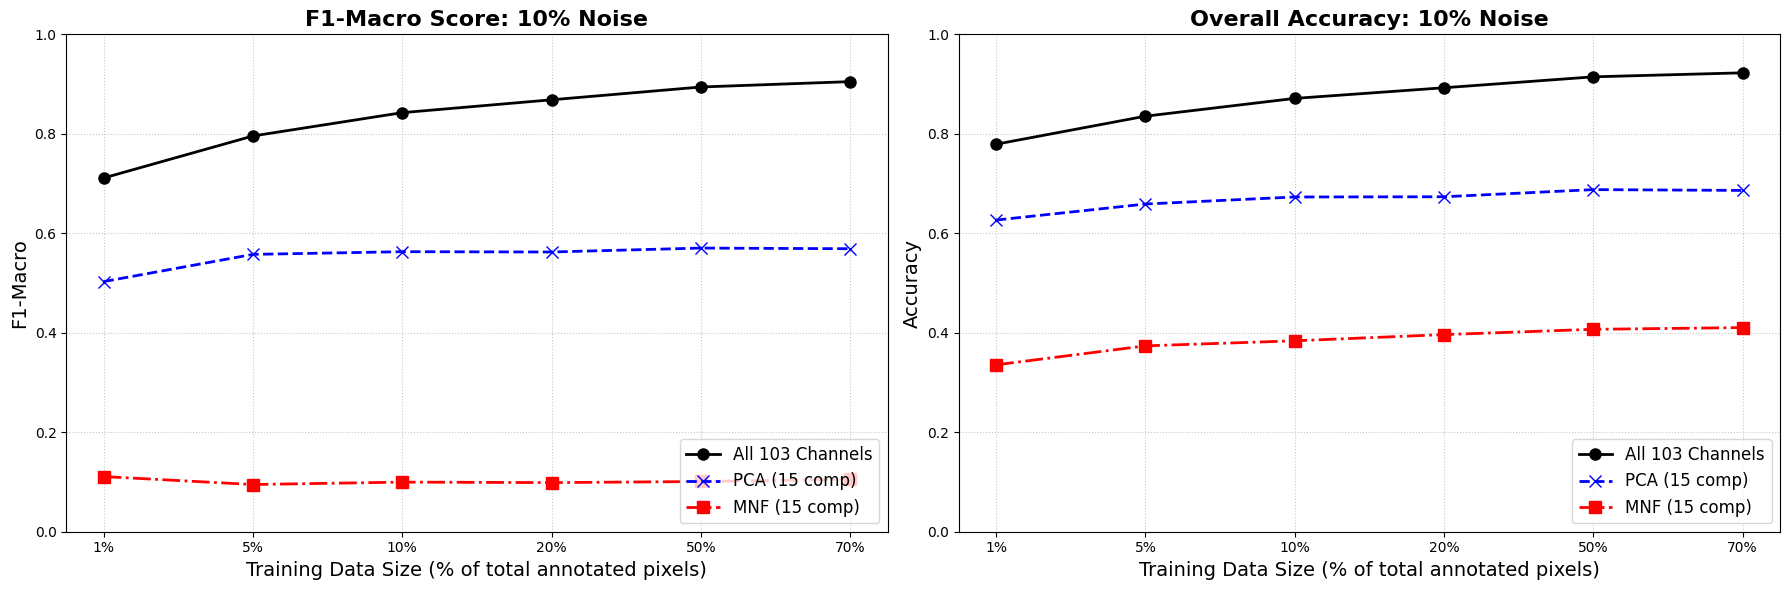


=== RESULTS TABLE: F1-MACRO (10% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7112  0.7956  0.8426  0.8684  0.8941  0.9049
PCA (15 comp)     0.5029  0.5576  0.5630  0.5624  0.5703  0.5690
MNF (15 comp)     0.1109  0.0949  0.0998  0.0987  0.1010  0.1053

=== RESULTS TABLE: OVERALL ACCURACY (10% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7791  0.8354  0.8712  0.8926  0.9146  0.9226
PCA (15 comp)     0.6266  0.6588  0.6730  0.6734  0.6878  0.6862
MNF (15 comp)     0.3356  0.3737  0.3838  0.3963  0.4070  0.4104

▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



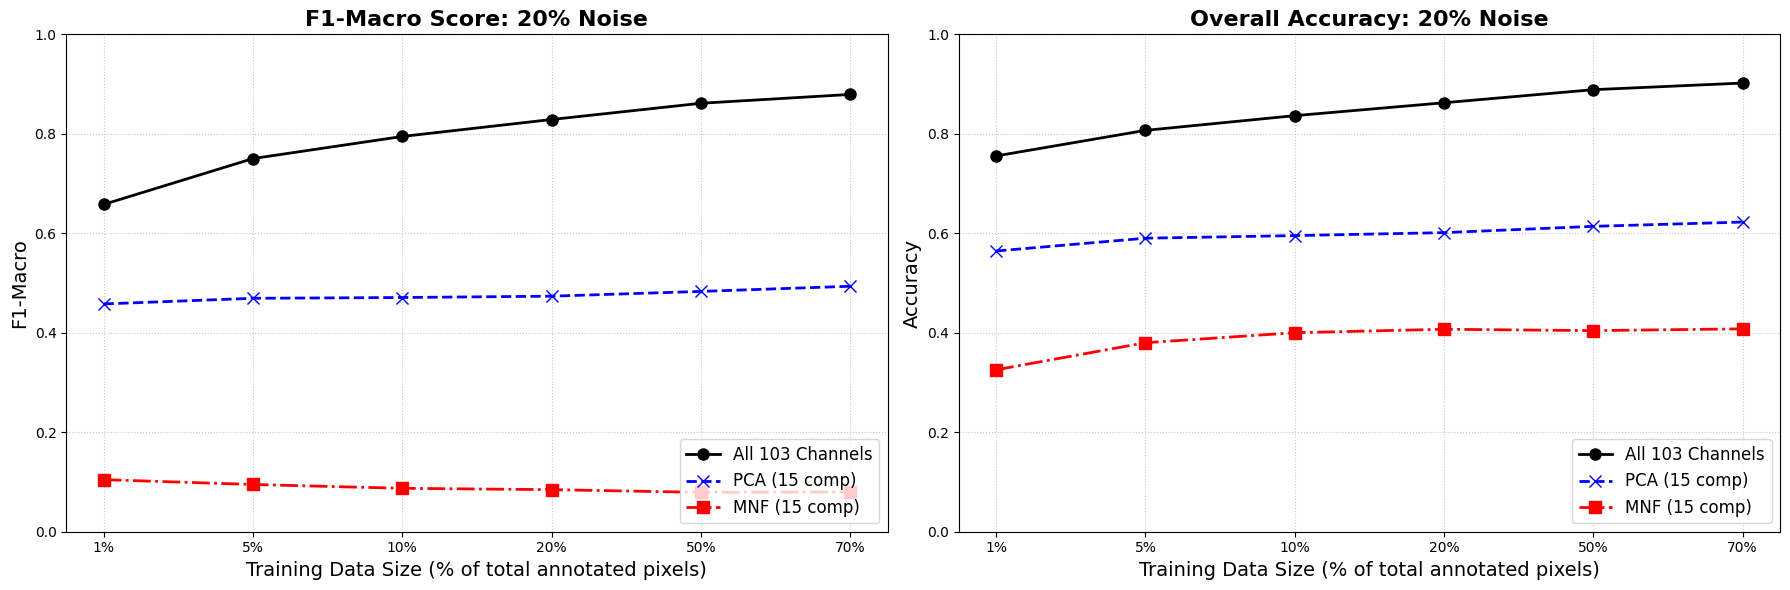


=== RESULTS TABLE: F1-MACRO (20% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.6580  0.7502  0.7947  0.8288  0.8614  0.8792
PCA (15 comp)     0.4580  0.4693  0.4709  0.4736  0.4831  0.4935
MNF (15 comp)     0.1047  0.0950  0.0873  0.0846  0.0792  0.0799

=== RESULTS TABLE: OVERALL ACCURACY (20% Noise) ===
Train Size            1%      5%     10%     20%     50%     70%
All 103 Channels  0.7555  0.8069  0.8365  0.8624  0.8887  0.9021
PCA (15 comp)     0.5644  0.5901  0.5954  0.6013  0.6140  0.6226
MNF (15 comp)     0.3255  0.3800  0.4001  0.4071  0.4043  0.4079

▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



In [40]:
# =============================================================================
# MAIN 3: COMPREHENSIVE DEGRADATION ANALYSIS (103 Ch vs PCA vs MNF)
# =============================================================================
"""
The primary difference is that MAIN 2 serves as a baseline sanity check, evaluating the XGBoost models solely on the original, clean dataset.
Conversely, MAIN 3 is a comprehensive stress test that automatically iterates through multiple noise levels (0% to 20%),
dynamically recalculating the PCA and MNF spatial transformations for each degraded dataset to evaluate the algorithm's robustness against impulse noise.
"""
print("[*] 1. Initializing global experiment...")

# 1. Creating a dictionary of all datasets for testing (Clean + Noisy)
# Using the data (clean) and noisy_datasets (from Main 1) variables
datasets_to_evaluate = {
    0.0: data,
    0.01: noisy_datasets[0.01],
    0.05: noisy_datasets[0.05],
    0.10: noisy_datasets[0.10],
    0.20: noisy_datasets[0.20]
}

valid_mask = (gt != 0)
h, w = gt.shape
y = gt.flatten()[valid_mask.flatten()] - 1

train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]

# Dictionaries to store all results
all_results_f1 = {}
all_results_acc = {}

# =============================================================================
# FEATURE EXTRACTION AND TRAINING
# =============================================================================
for noise_level, current_cube in datasets_to_evaluate.items():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean)"
    print(f"\n{'='*60}")
    print(f"[*] EXPERIMENT: {noise_str}")
    print(f"{'='*60}")
    
    scaler = StandardScaler()
    cube_2d = current_cube.reshape(h * w, -1)
    
    # 1. All 103 channels
    print("  -> Preparing All 103 Channels...")
    X_103 = scaler.fit_transform(cube_2d[valid_mask.flatten()])
    
    # 2. PCA (15 components)
    print("  -> Performing PCA (103 -> 15)...")
    pca = PCA(n_components=15)
    reduced_pca = pca.fit_transform(cube_2d)
    X_pca = scaler.fit_transform(reduced_pca[valid_mask.flatten()])
    
    # 3. MNF (15 components)
    print("  -> Performing MNF (103 -> 15)...")
    reduced_mnf_cube = perform_mnf(current_cube, n_components=15)
    reduced_mnf_2d = reduced_mnf_cube.reshape(h * w, -1)
    X_mnf = scaler.fit_transform(reduced_mnf_2d[valid_mask.flatten()])
    
    models = {
        "All 103 Channels": X_103,
        "PCA (15 comp)": X_pca,
        "MNF (15 comp)": X_mnf
    }
    
    results_f1 = {}
    results_acc = {}
    
    print(f"\n  [*] Training XGBoost models for {noise_str}...")
    for model_name, X_data in models.items():
        print(f"      Training: {model_name}...")
        f1_list, acc_list, time_list = evaluate_learning_curve(X_data, y, train_fractions, test_size=0.2)
        results_f1[model_name] = f1_list
        results_acc[model_name] = acc_list
        
    all_results_f1[noise_level] = results_f1
    all_results_acc[noise_level] = results_acc

print("\n[+] All experiments completed! Generating plots and tables...")

# =============================================================================
# VISUALIZATION AND TABLE GENERATION
# =============================================================================
styles = {
    "All 103 Channels": {"color": "black", "linestyle": "-", "marker": "o"},
    "PCA (15 comp)": {"color": "blue", "linestyle": "--", "marker": "x"},
    "MNF (15 comp)": {"color": "red", "linestyle": "-.", "marker": "s"}
}

for noise_level in datasets_to_evaluate.keys():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean Data)"
    results_f1 = all_results_f1[noise_level]
    results_acc = all_results_acc[noise_level]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: F1-Macro
    for model_name, scores in results_f1.items():
        s = styles[model_name]
        axes[0].plot(fraction_labels, scores, label=model_name, 
                     color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)
        
    axes[0].set_title(f"F1-Macro Score: {noise_str}", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
    axes[0].set_ylabel("F1-Macro", fontsize=14)
    axes[0].set_ylim(0.0, 1.0) # Fix the axis from 0 to 1 for fair comparison
    axes[0].grid(True, linestyle=':', alpha=0.7)
    axes[0].legend(loc='lower right', fontsize=12)
    
    # Plot 2: Overall Accuracy
    for model_name, scores in results_acc.items():
        s = styles[model_name]
        axes[1].plot(fraction_labels, scores, label=model_name, 
                     color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2, markersize=8)
        
    axes[1].set_title(f"Overall Accuracy: {noise_str}", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("Training Data Size (% of total annotated pixels)", fontsize=14)
    axes[1].set_ylabel("Accuracy", fontsize=14)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, linestyle=':', alpha=0.7)
    axes[1].legend(loc='lower right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Output tables for the current noise level
    df_f1 = pd.DataFrame(results_f1, index=fraction_labels).T
    df_f1.columns.name = "Train Size"
    
    df_acc = pd.DataFrame(results_acc, index=fraction_labels).T
    df_acc.columns.name = "Train Size"
    
    print(f"\n=== RESULTS TABLE: F1-MACRO ({noise_str}) ===")
    print(df_f1.round(4))
    
    print(f"\n=== RESULTS TABLE: OVERALL ACCURACY ({noise_str}) ===")
    print(df_acc.round(4))
    print("\n" + "▰" * 80 + "\n")

[*] 1. Initializing global experiment (Maximum Main 3.1)...

[*] RUNNING EXPERIMENT: 0% Noise (Clean Data)
  -> Preparing Baseline 1: All 103 Channels...
  -> Preparing Baseline 2: MNF (103 -> 15)...
[*] 1/4: Estimating noise covariance matrix...
[*] 2/4: Estimating data covariance matrix...
[*] 3/4: Solving the generalized eigenvalue problem...
[*] 4/4: Sorting and projection onto 15 components...
  -> Comprehensive spatial feature extraction (RGB / LBP / TEG Light / TEG Heavy)...
      [~] Starting heavy TEG extraction for all 103 channels. This will take some time...

  [*] Starting curve construction (Accuracy + Time)...
      Processing: Baseline: All 103 Channels (Features: 103) | Training [10%]: 2.53s, Inference [20%]: 0.02s
      Processing: Baseline: MNF (15 comp) (Features: 15) | Training [10%]: 1.80s, Inference [20%]: 0.02s
      Processing: Ablation 1: Noisy RGB (Features: 3) | Training [10%]: 2.71s, Inference [20%]: 0.03s
      Processing: Ablation 2: RGB + LBP (Features: 

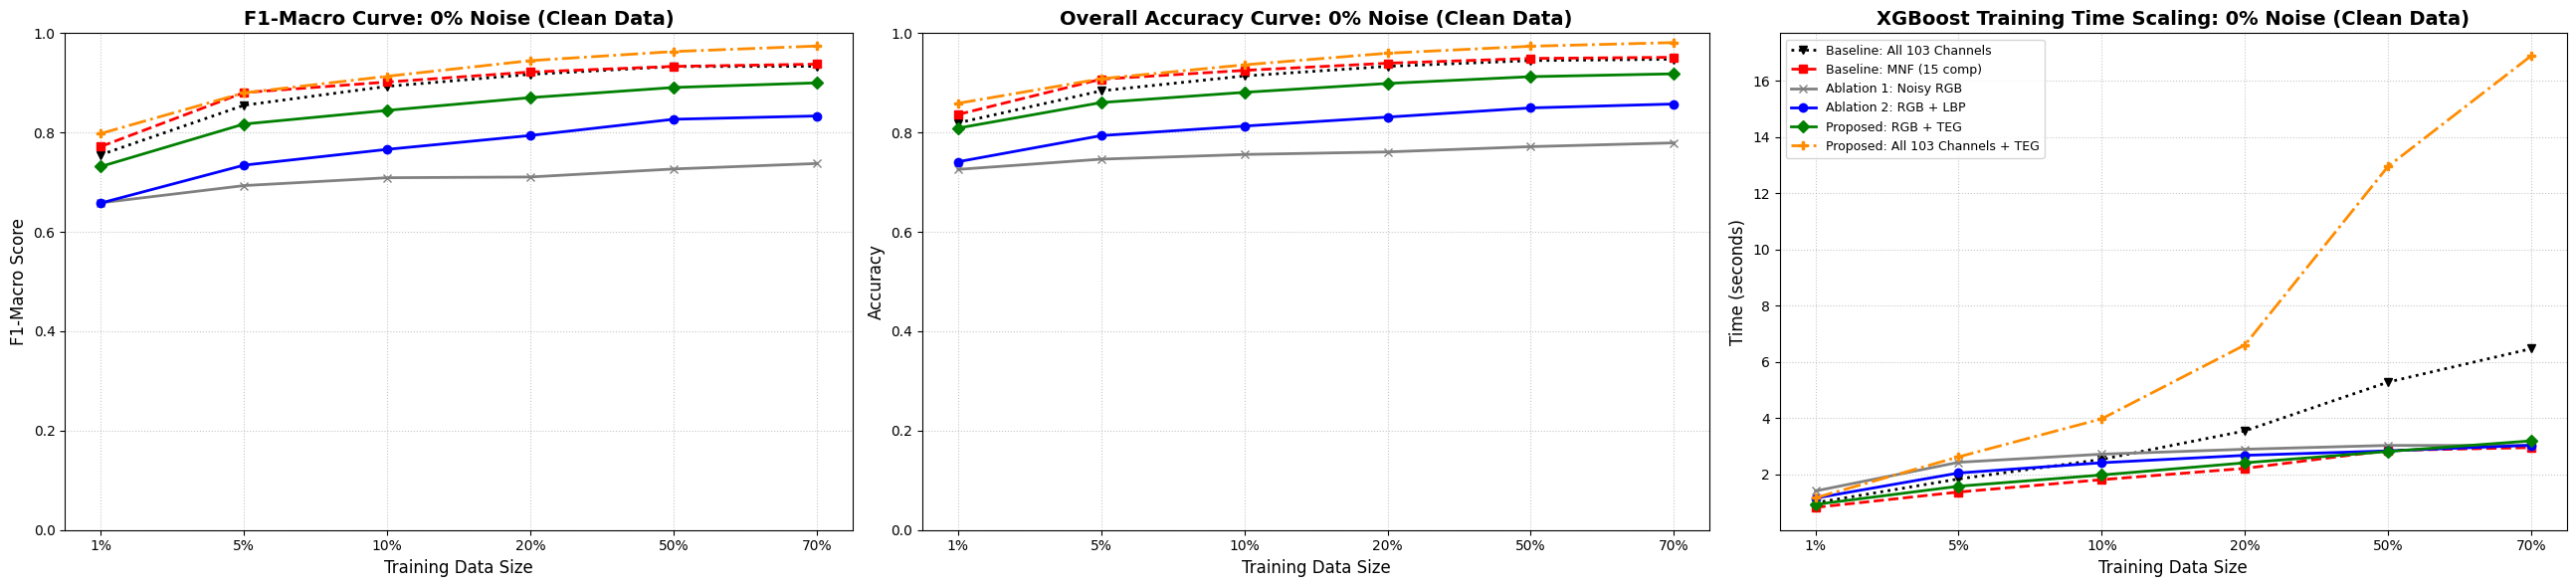


[ 🎯 METRIC: F1-MACRO SCORE - 0% Noise (Clean Data) ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7553,0.8549,0.8929,0.9171,0.9328,0.9334
Baseline: MNF (15 comp),0.7718,0.8804,0.9017,0.9218,0.9331,0.9376
Ablation 1: Noisy RGB,0.6585,0.6932,0.7090,0.7105,0.7266,0.7376
Ablation 2: RGB + LBP,0.6581,0.7343,0.7661,0.7940,0.8267,0.8333
Proposed: RGB + TEG,0.7316,0.8171,0.8446,0.8703,0.8907,0.9000
Proposed: All 103 Channels + TEG,0.7980,0.8799,0.9132,0.9447,0.9630,0.9741



[ 🎯 METRIC: OVERALL ACCURACY - 0% Noise (Clean Data) ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.8194,0.8839,0.9139,0.9333,0.9448,0.9475
Baseline: MNF (15 comp),0.8364,0.9074,0.9251,0.9396,0.9492,0.9515
Ablation 1: Noisy RGB,0.7258,0.7464,0.7558,0.7610,0.7716,0.7792
Ablation 2: RGB + LBP,0.7412,0.7938,0.8130,0.8311,0.8496,0.8574
Proposed: RGB + TEG,0.8089,0.8603,0.8809,0.8988,0.9125,0.9182
Proposed: All 103 Channels + TEG,0.8588,0.9083,0.9363,0.9597,0.9737,0.9811



[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - 0% Noise (Clean Data) ]


...


[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.978,1.827,2.525,3.540,5.278,6.467
Baseline: MNF (15 comp),0.814,1.363,1.803,2.205,2.843,2.945
Ablation 1: Noisy RGB,1.399,2.421,2.710,2.886,3.023,3.020
Ablation 2: RGB + LBP,1.145,2.040,2.406,2.669,2.828,3.028
Proposed: RGB + TEG,0.920,1.569,1.969,2.403,2.808,3.185
Proposed: All 103 Channels + TEG,1.156,2.615,3.971,6.601,12.961,16.901



[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.0079,0.0144,0.0227,0.0274,0.0337,0.0336
Baseline: MNF (15 comp),0.0187,0.0383,0.0426,0.0387,0.0346,0.0363
Ablation 1: Noisy RGB,0.0162,0.0319,0.0385,0.0406,0.0428,0.0444
Ablation 2: RGB + LBP,0.0165,0.0345,0.0405,0.0438,0.0391,0.0377
Proposed: RGB + TEG,0.0111,0.0254,0.0334,0.0381,0.0410,0.0371
Proposed: All 103 Channels + TEG,0.0077,0.0137,0.0178,0.0273,0.0315,0.0347



▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



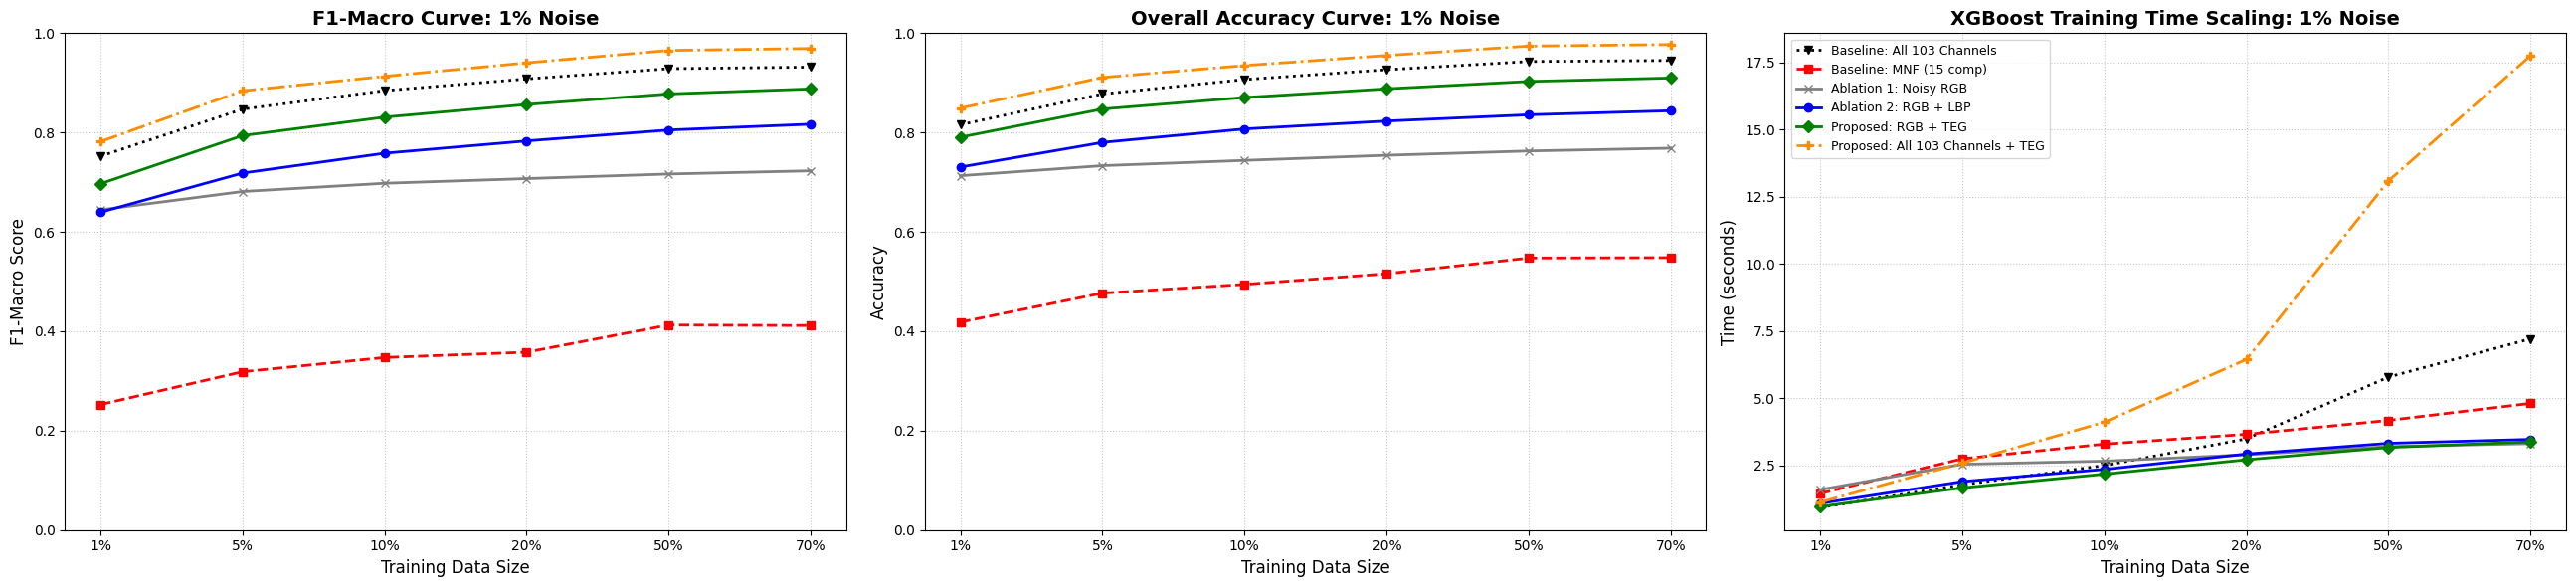


[ 🎯 METRIC: F1-MACRO SCORE - 1% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7522,0.8470,0.8844,0.9079,0.9286,0.9317
Baseline: MNF (15 comp),0.2525,0.3185,0.3472,0.3579,0.4125,0.4115
Ablation 1: Noisy RGB,0.6442,0.6812,0.6978,0.7073,0.7165,0.7229
Ablation 2: RGB + LBP,0.6395,0.7183,0.7583,0.7831,0.8050,0.8167
Proposed: RGB + TEG,0.6969,0.7937,0.8309,0.8564,0.8777,0.8878
Proposed: All 103 Channels + TEG,0.7817,0.8839,0.9131,0.9403,0.9652,0.9692



[ 🎯 METRIC: OVERALL ACCURACY - 1% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.8156,0.8776,0.9067,0.9265,0.9430,0.9451
Baseline: MNF (15 comp),0.4183,0.4767,0.4944,0.5159,0.5475,0.5482
Ablation 1: Noisy RGB,0.7131,0.7333,0.7439,0.7542,0.7629,0.7685
Ablation 2: RGB + LBP,0.7305,0.7800,0.8072,0.8230,0.8357,0.8439
Proposed: RGB + TEG,0.7906,0.8472,0.8705,0.8880,0.9029,0.9098
Proposed: All 103 Channels + TEG,0.8491,0.9108,0.9349,0.9551,0.9741,0.9771



[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - 1% Noise ]


...


[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.936,1.778,2.499,3.491,5.790,7.212
Baseline: MNF (15 comp),1.453,2.749,3.296,3.659,4.176,4.811
Ablation 1: Noisy RGB,1.596,2.543,2.661,2.897,3.202,3.312
Ablation 2: RGB + LBP,1.086,1.899,2.354,2.926,3.325,3.470
Proposed: RGB + TEG,0.968,1.665,2.178,2.713,3.169,3.379
Proposed: All 103 Channels + TEG,1.131,2.587,4.110,6.445,13.093,17.750



[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.0073,0.0168,0.0204,0.0300,0.0345,0.0457
Baseline: MNF (15 comp),0.0266,0.0344,0.0511,0.0397,0.0394,0.0344
Ablation 1: Noisy RGB,0.0210,0.0341,0.0426,0.0398,0.0401,0.0373
Ablation 2: RGB + LBP,0.0163,0.0333,0.0420,0.0417,0.0431,0.0413
Proposed: RGB + TEG,0.0102,0.0271,0.0347,0.0435,0.1132,0.0390
Proposed: All 103 Channels + TEG,0.0099,0.0160,0.0184,0.0242,0.0340,0.0460



▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



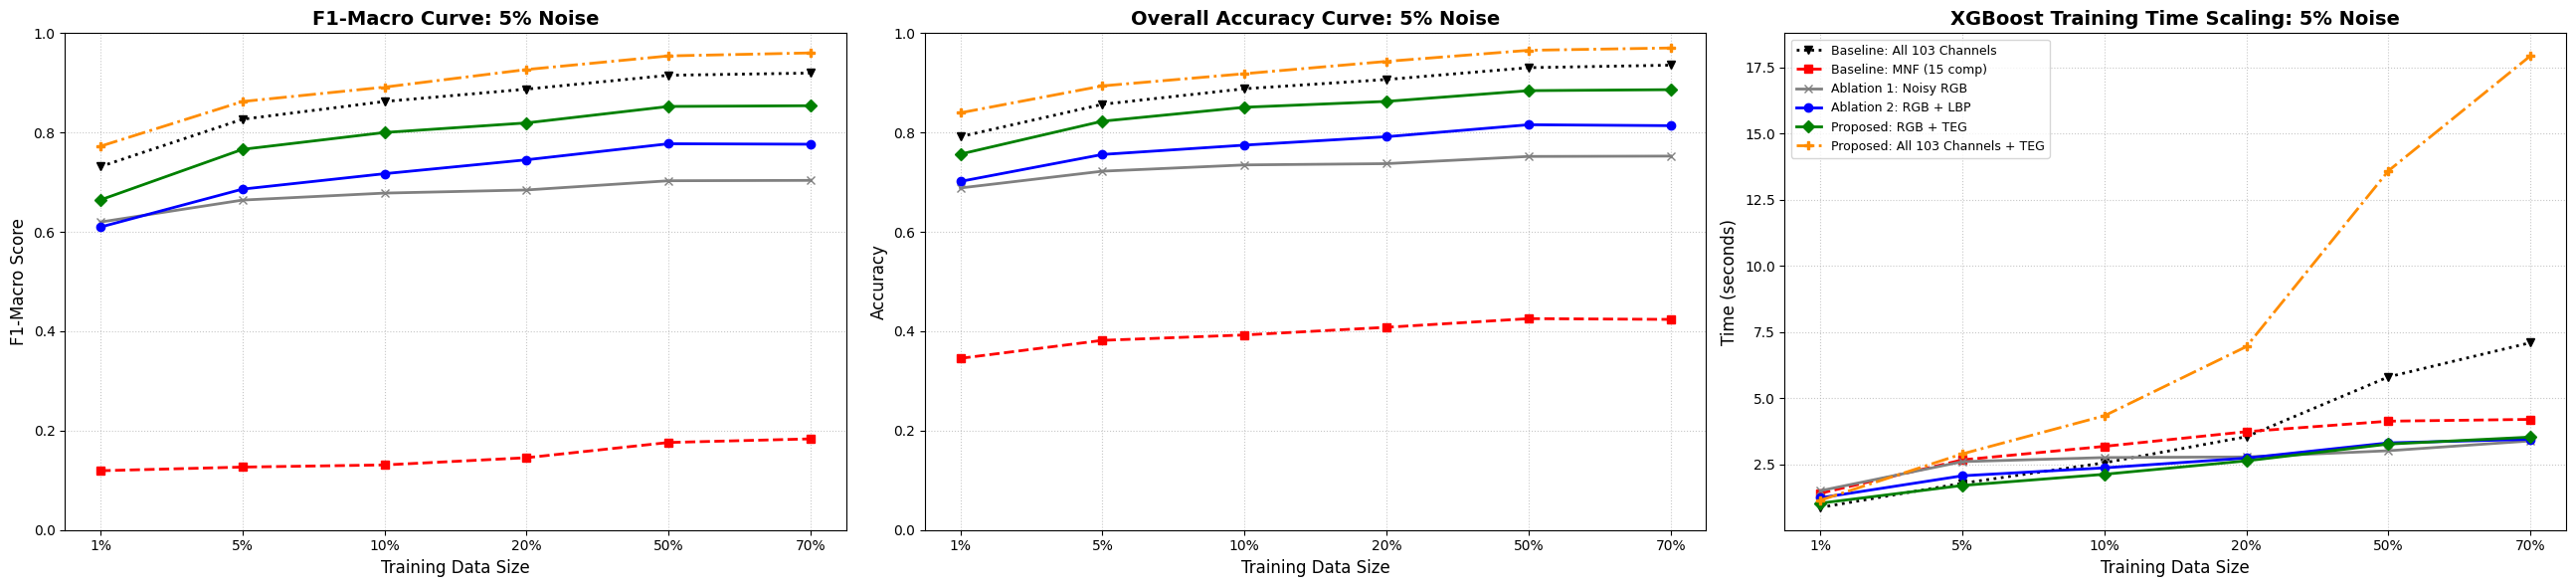


[ 🎯 METRIC: F1-MACRO SCORE - 5% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7315,0.8267,0.8625,0.8873,0.9153,0.9197
Baseline: MNF (15 comp),0.1193,0.1267,0.1310,0.1455,0.1762,0.1835
Ablation 1: Noisy RGB,0.6199,0.6640,0.6781,0.6844,0.7030,0.7037
Ablation 2: RGB + LBP,0.6098,0.6861,0.7172,0.7452,0.7774,0.7765
Proposed: RGB + TEG,0.6644,0.7661,0.8001,0.8194,0.8525,0.8540
Proposed: All 103 Channels + TEG,0.7724,0.8624,0.8914,0.9268,0.9542,0.9602



[ 🎯 METRIC: OVERALL ACCURACY - 5% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7917,0.8568,0.8881,0.9067,0.9306,0.9356
Baseline: MNF (15 comp),0.3455,0.3817,0.3926,0.4080,0.4254,0.4239
Ablation 1: Noisy RGB,0.6884,0.7222,0.7348,0.7374,0.7519,0.7526
Ablation 2: RGB + LBP,0.7016,0.7558,0.7747,0.7916,0.8157,0.8138
Proposed: RGB + TEG,0.7565,0.8228,0.8509,0.8627,0.8843,0.8863
Proposed: All 103 Channels + TEG,0.8396,0.8939,0.9184,0.9432,0.9655,0.9702



[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - 5% Noise ]


...


[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.874,1.787,2.561,3.547,5.808,7.101
Baseline: MNF (15 comp),1.407,2.672,3.183,3.738,4.134,4.202
Ablation 1: Noisy RGB,1.505,2.605,2.759,2.783,3.018,3.388
Ablation 2: RGB + LBP,1.237,2.070,2.370,2.740,3.314,3.448
Proposed: RGB + TEG,1.035,1.705,2.127,2.635,3.269,3.533
Proposed: All 103 Channels + TEG,1.145,2.899,4.338,6.954,13.598,17.944



[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.0084,0.0170,0.0200,0.0272,0.0335,0.0339
Baseline: MNF (15 comp),0.0188,0.0390,0.0434,0.0403,0.0446,0.0388
Ablation 1: Noisy RGB,0.0182,0.0405,0.0376,0.0390,0.0461,0.0369
Ablation 2: RGB + LBP,0.0149,0.0319,0.0367,0.0378,0.0367,0.0533
Proposed: RGB + TEG,0.0093,0.0232,0.0333,0.0374,0.0379,0.0414
Proposed: All 103 Channels + TEG,0.0080,0.0169,0.0204,0.0248,0.0314,0.0351



▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



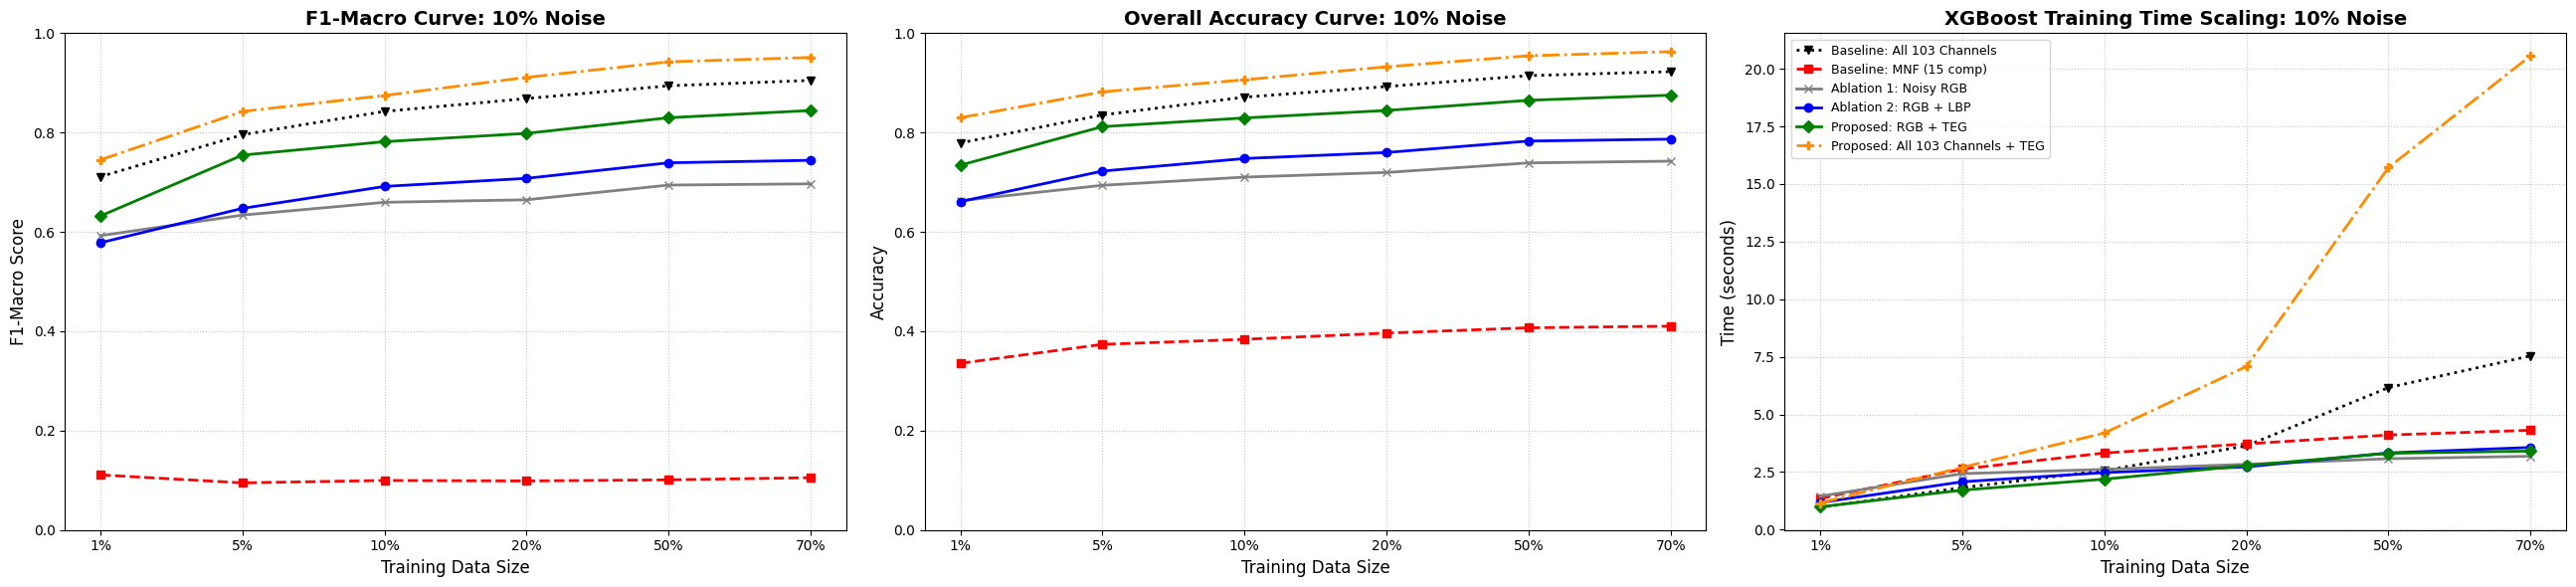


[ 🎯 METRIC: F1-MACRO SCORE - 10% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7112,0.7956,0.8426,0.8684,0.8941,0.9049
Baseline: MNF (15 comp),0.1109,0.0949,0.0998,0.0987,0.1010,0.1053
Ablation 1: Noisy RGB,0.5925,0.6338,0.6596,0.6647,0.6942,0.6968
Ablation 2: RGB + LBP,0.5782,0.6474,0.6915,0.7078,0.7391,0.7441
Proposed: RGB + TEG,0.6320,0.7546,0.7816,0.7983,0.8298,0.8444
Proposed: All 103 Channels + TEG,0.7450,0.8424,0.8746,0.9110,0.9423,0.9511



[ 🎯 METRIC: OVERALL ACCURACY - 10% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7791,0.8354,0.8712,0.8926,0.9146,0.9226
Baseline: MNF (15 comp),0.3356,0.3737,0.3838,0.3963,0.4070,0.4104
Ablation 1: Noisy RGB,0.6628,0.6938,0.7103,0.7196,0.7389,0.7424
Ablation 2: RGB + LBP,0.6609,0.7224,0.7477,0.7598,0.7828,0.7867
Proposed: RGB + TEG,0.7343,0.8118,0.8294,0.8444,0.8649,0.8752
Proposed: All 103 Channels + TEG,0.8298,0.8820,0.9061,0.9323,0.9545,0.9628



[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - 10% Noise ]


...


[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.964,1.823,2.566,3.638,6.165,7.542
Baseline: MNF (15 comp),1.356,2.630,3.327,3.723,4.107,4.314
Ablation 1: Noisy RGB,1.452,2.430,2.616,2.836,3.079,3.185
Ablation 2: RGB + LBP,1.175,2.077,2.476,2.723,3.329,3.568
Proposed: RGB + TEG,0.990,1.715,2.191,2.783,3.314,3.410
Proposed: All 103 Channels + TEG,1.158,2.704,4.194,7.081,15.716,20.568



[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.0073,0.0181,0.0209,0.0253,0.0335,0.0348
Baseline: MNF (15 comp),0.0199,0.0398,0.0406,0.0401,0.0377,0.0356
Ablation 1: Noisy RGB,0.0254,0.0366,0.0434,0.0384,0.0545,0.0442
Ablation 2: RGB + LBP,0.0201,0.0316,0.0462,0.0416,0.0393,0.0502
Proposed: RGB + TEG,0.0096,0.0224,0.0309,0.0379,0.0391,0.0394
Proposed: All 103 Channels + TEG,0.0069,0.0143,0.0196,0.0274,0.0322,0.0378



▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



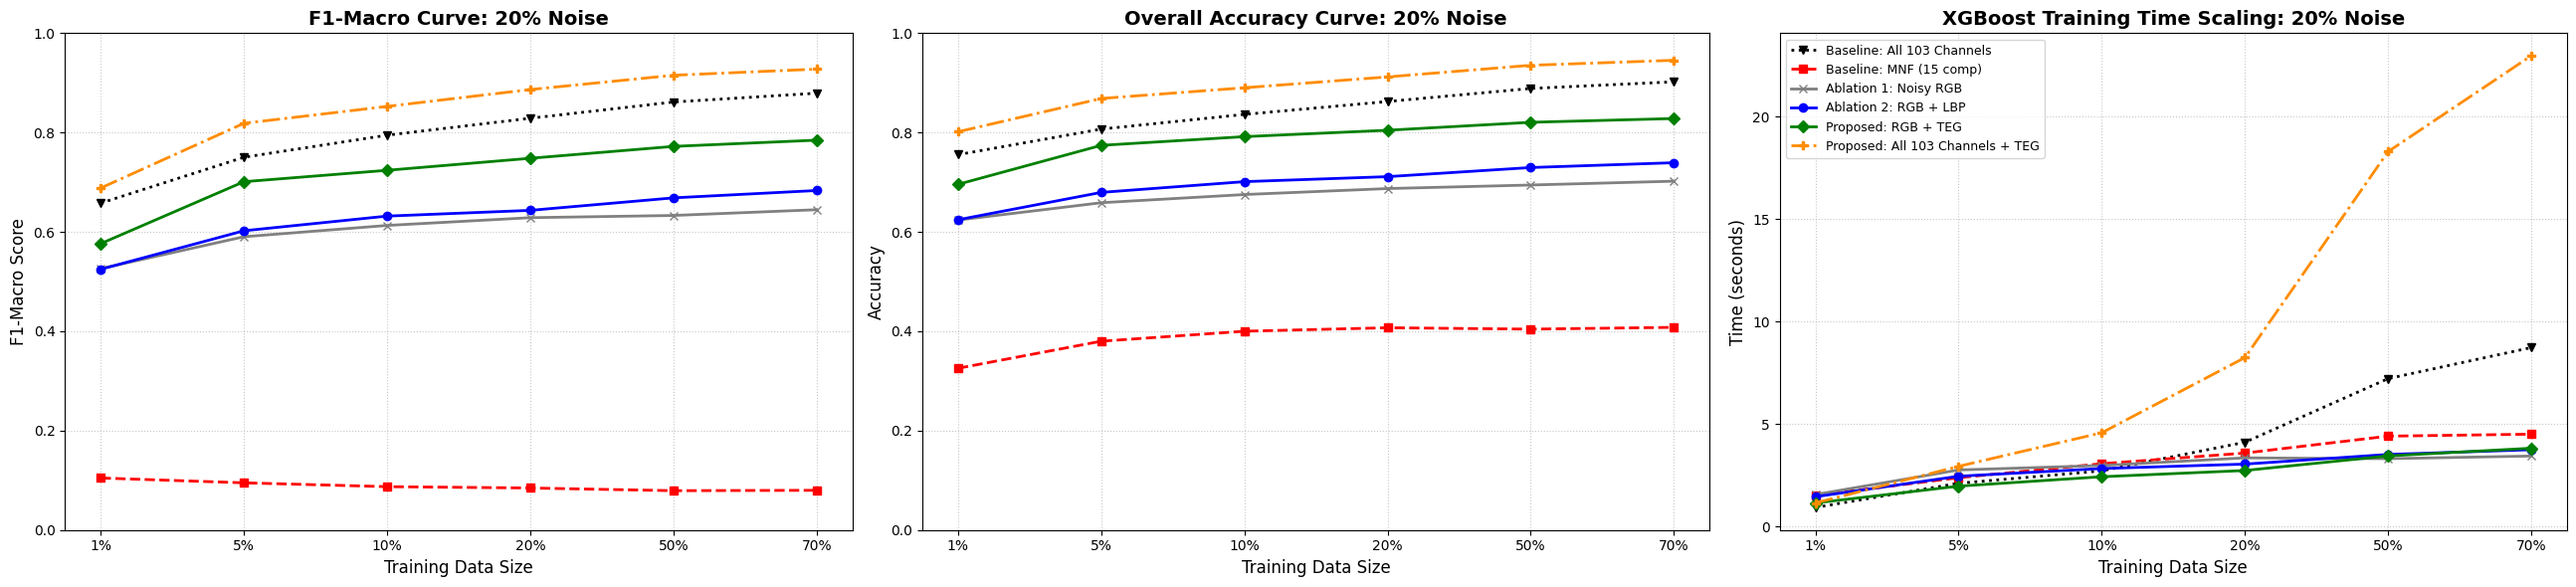


[ 🎯 METRIC: F1-MACRO SCORE - 20% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.6580,0.7502,0.7947,0.8288,0.8614,0.8792
Baseline: MNF (15 comp),0.1047,0.0950,0.0873,0.0846,0.0792,0.0799
Ablation 1: Noisy RGB,0.5260,0.5903,0.6130,0.6286,0.6331,0.6447
Ablation 2: RGB + LBP,0.5248,0.6023,0.6318,0.6434,0.6685,0.6833
Proposed: RGB + TEG,0.5764,0.7010,0.7240,0.7482,0.7721,0.7846
Proposed: All 103 Channels + TEG,0.6883,0.8186,0.8526,0.8865,0.9153,0.9277



[ 🎯 METRIC: OVERALL ACCURACY - 20% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: All 103 Channels,0.7555,0.8069,0.8365,0.8624,0.8887,0.9021
Baseline: MNF (15 comp),0.3255,0.3800,0.4001,0.4071,0.4043,0.4079
Ablation 1: Noisy RGB,0.6239,0.6587,0.6752,0.6872,0.6944,0.7021
Ablation 2: RGB + LBP,0.6245,0.6795,0.7011,0.7112,0.7295,0.7392
Proposed: RGB + TEG,0.6958,0.7742,0.7917,0.8046,0.8206,0.8282
Proposed: All 103 Channels + TEG,0.8015,0.8685,0.8901,0.9120,0.9354,0.9454



[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - 20% Noise ]


...


[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.928,2.107,2.715,4.112,7.218,8.734
Baseline: MNF (15 comp),1.514,2.381,3.063,3.584,4.410,4.506
Ablation 1: Noisy RGB,1.558,2.759,2.976,3.349,3.309,3.438
Ablation 2: RGB + LBP,1.452,2.452,2.828,3.045,3.516,3.747
Proposed: RGB + TEG,1.146,1.968,2.427,2.732,3.444,3.820
Proposed: All 103 Channels + TEG,1.148,2.935,4.575,8.245,18.305,22.986



[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]


,1%,5%,10%,20%,50%,70%
Model Architecture,,,,,,
Baseline: All 103 Channels,0.0070,0.0197,0.0279,0.0357,0.0328,0.0405
Baseline: MNF (15 comp),0.0190,0.0532,0.0408,0.0503,0.0440,0.0409
Ablation 1: Noisy RGB,0.0198,0.0445,0.0402,0.0418,0.0394,0.0439
Ablation 2: RGB + LBP,0.0169,0.0342,0.0395,0.0462,0.0420,0.0430
Proposed: RGB + TEG,0.0102,0.0320,0.0300,0.0349,0.0422,0.0401
Proposed: All 103 Channels + TEG,0.0083,0.0178,0.0198,0.0242,0.0384,0.0455



▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰



In [42]:
# =============================================================================
# MAIN 3.1: MAXIMUM COMPREHENSIVE ABLATION & END-TO-END BENCHMARKING (618 Feat)
# =============================================================================
"""
=============================================================================
Comprehensive Ablation Study & Benchmarking Pipeline
=============================================================================
This script evaluates the robustness of various hyperspectral feature extraction 
methods (including Baseline 103-Ch, MNF, LBP, and the proposed TEG descriptor) 
against impulse (Salt & Pepper) noise using an XGBoost classifier. 

It systematically performs the following:
1. Simulates dynamic spatial degradation across multiple noise levels (0% - 20%).
2. Extracts complex spatial-spectral features (scaling up to 618 features per pixel).
3. Generates learning curves to assess data efficiency.
4. Benchmarks end-to-end performance, comparing classification accuracy 
   (F1-Macro, Overall Accuracy) against computational complexity (Extraction, 
   Training, and Inference times).
"""
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from skimage.feature import local_binary_pattern
from skimage.filters import sobel
from skimage.morphology import disk
from skimage.filters.rank import entropy

warnings.filterwarnings('ignore')

print("[*] 1. Initializing global experiment (Maximum Main 3.1)...")

# -------------------------------------------------------------------------
# HELPER FUNCTION 1: Maximum feature extraction (Including all 103 channels)
# -------------------------------------------------------------------------
def get_all_ablation_matrices_heavy(cube, gt_mask):
    """Returns normalized feature matrices for light and heavy (103 Ch + TEG) configurations"""
    times = {}
    h, w, b = cube.shape
    valid = gt_mask.flatten()
    scaler = StandardScaler()
    
    # --- 1. Light block: RGB and basic TEG on 3 channels ---
    t0 = time.time()
    rgb = get_rgb_image(cube)
    X_rgb = scaler.fit_transform(rgb.reshape(h * w, -1)[valid])
    times["Ablation 1: Noisy RGB"] = time.time() - t0
    
    t_start_light = time.time()
    lbp_configs = [(1, 8), (2, 16), (3, 24)]
    features_lbp = [rgb]
    features_teg_light = [rgb]
    
    for ch_idx in range(3):
        ch = rgb[:, :, ch_idx]
        grad = sobel(ch)[:, :, np.newaxis]
        ch_8bit = (ch * 255).astype(np.uint8)
        ent = entropy(ch_8bit, disk(3))[:, :, np.newaxis]
        
        lbp_list = []
        for r, p in lbp_configs:
            lbp_map = local_binary_pattern(ch, p, r, method='uniform')
            lbp_list.append((lbp_map / lbp_map.max())[:, :, np.newaxis])
            
        lbp_combined = np.concatenate(lbp_list, axis=2)
        features_lbp.append(lbp_combined)
        features_teg_light.extend([grad, ent, lbp_combined])
        
    extraction_overhead_light = time.time() - t_start_light
    
    t0 = time.time()
    X_rgb_lbp = scaler.fit_transform(np.concatenate(features_lbp, axis=2).reshape(h * w, -1)[valid])
    times["Ablation 2: RGB + LBP"] = times["Ablation 1: Noisy RGB"] + extraction_overhead_light + (time.time() - t0)
    
    t0 = time.time()
    X_teg_light = scaler.fit_transform(np.concatenate(features_teg_light, axis=2).reshape(h * w, -1)[valid])
    times["Proposed: RGB + TEG"] = times["Ablation 1: Noisy RGB"] + extraction_overhead_light + (time.time() - t0)
    
    # --- 2. HEAVY BLOCK: TEG on all 103 channels (618 features per pixel) ---
    print(f"      [~] Starting heavy TEG extraction for all {b} channels. This will take some time...")
    t_start_heavy = time.time()
    
    # Normalize the entire 103-channel cube to the [0, 1] range for correct Entropy and LBP operation
    cube_flat = cube.reshape(-1, b)
    cube_norm = (cube_flat - cube_flat.min(axis=0)) / (cube_flat.max(axis=0) - cube_flat.min(axis=0) + 1e-8)
    cube_norm = cube_norm.reshape(cube.shape)
    
    features_heavy = [cube_norm] # The base cube serves as the foundation
    
    for ch_idx in range(b):
        ch = cube_norm[:, :, ch_idx]
        
        # 1. Sobel Gradient
        grad = sobel(ch)[:, :, np.newaxis]
        
        # 2. Entropy (conversion to 8-bit integer format)
        ch_8bit = (ch * 255).astype(np.uint8)
        ent = entropy(ch_8bit, disk(3))[:, :, np.newaxis]
        
        # 3. Three LBP scales
        lbp_list = []
        for r, p in lbp_configs:
            lbp_map = local_binary_pattern(ch, p, r, method='uniform')
            lbp_list.append((lbp_map / (lbp_map.max() + 1e-8))[:, :, np.newaxis])
            
        lbp_combined = np.concatenate(lbp_list, axis=2)
        
        # Add all 5 new feature layers for the current channel
        features_heavy.extend([grad, ent, lbp_combined])
        
    # Concatenate all 618 layers together
    heavy_cube = np.concatenate(features_heavy, axis=2)
    
    t0 = time.time()
    X_teg_heavy = scaler.fit_transform(heavy_cube.reshape(h * w, -1)[valid])
    times["Proposed: All 103 Channels + TEG"] = (time.time() - t_start_heavy) + (time.time() - t0)
    
    return X_rgb, X_rgb_lbp, X_teg_light, X_teg_heavy, times


# -------------------------------------------------------------------------
# EXPERIMENT SETUP
# -------------------------------------------------------------------------
datasets_to_evaluate = {
    0.0: data,                # Clean data
    0.01: noisy_datasets[0.01], # 1% noise
    0.05: noisy_datasets[0.05], # 5% noise
    0.10: noisy_datasets[0.10], # 10% noise
    0.20: noisy_datasets[0.20]  # 20% noise
}

valid_mask = (gt != 0)
y = gt.flatten()[valid_mask.flatten()] - 1

train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]

all_results_f1 = {}
all_results_acc = {}
all_results_time = {} 
all_extraction_times = {} 

# =============================================================================
# MAIN PROCESSING AND TRAINING LOOP
# =============================================================================
start_time_global = time.time()

for noise_level, current_cube in datasets_to_evaluate.items():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean Data)"
    print(f"\n{'='*85}")
    print(f"[*] RUNNING EXPERIMENT: {noise_str}")
    print(f"{'='*85}")
    
    feat_extraction_times = {}
    
    # --- Baseline spectral feature extraction ---
    print("  -> Preparing Baseline 1: All 103 Channels...")
    t0 = time.time()
    cube_2d = current_cube.reshape(gt.size, -1)
    X_103 = StandardScaler().fit_transform(cube_2d[valid_mask.flatten()])
    feat_extraction_times["Baseline: All 103 Channels"] = time.time() - t0
    
    print("  -> Preparing Baseline 2: MNF (103 -> 15)...")
    t0 = time.time()
    reduced_mnf_cube = perform_mnf(current_cube, n_components=15)
    X_mnf = StandardScaler().fit_transform(reduced_mnf_cube.reshape(gt.size, -1)[valid_mask.flatten()])
    feat_extraction_times["Baseline: MNF (15 comp)"] = time.time() - t0
    
    # --- Spatial descriptor extraction (including heavy variant) ---
    print("  -> Comprehensive spatial feature extraction (RGB / LBP / TEG Light / TEG Heavy)...")
    X_rgb, X_rgb_lbp, X_teg_light, X_teg_heavy, teg_times = get_all_ablation_matrices_heavy(current_cube, valid_mask)
    feat_extraction_times.update(teg_times)
    all_extraction_times[noise_level] = feat_extraction_times
    
    models = {
        "Baseline: All 103 Channels": X_103,
        "Baseline: MNF (15 comp)": X_mnf,
        "Ablation 1: Noisy RGB": X_rgb,
        "Ablation 2: RGB + LBP": X_rgb_lbp,
        "Proposed: RGB + TEG": X_teg_light,
        "Proposed: All 103 Channels + TEG": X_teg_heavy
    }
    
    results_f1 = {}
    results_acc = {}
    results_time = {}
    
    print(f"\n  [*] Starting curve construction (Accuracy + Time)...")
    for model_name, X_data in models.items():
        f1_list, acc_list, time_list = evaluate_learning_curve(X_data, y, train_fractions, test_size=0.2)
        results_f1[model_name] = f1_list
        results_acc[model_name] = acc_list
        results_time[model_name] = time_list
        
        # Computational indicators for quick text log
        features_count = X_data.shape[1]
        train_time_10pct = time_list[2] 
        
        # Measure isolated classifier inference time on 20% test data
        X_tr_p, X_te_p, y_tr_p, _ = train_test_split(X_data, y, test_size=0.2, stratify=y, random_state=42)
        clf_bench = xgb.XGBClassifier(
            objective='multi:softmax', n_estimators=200, max_depth=8, eta=0.3, 
            eval_metric='mlogloss', tree_method='hist', n_jobs=-1, random_state=42
        )
        clf_bench.fit(X_tr_p[:int(len(y)*0.1)], y_tr_p[:int(len(y)*0.1)])
        
        t_inf_start = time.time()
        _ = clf_bench.predict(X_te_p)
        infer_time_20pct = time.time() - t_inf_start
        
        print(f"      Processing: {model_name} (Features: {features_count}) | Training [10%]: {train_time_10pct:.2f}s, Inference [20%]: {infer_time_20pct:.2f}s")
        
    all_results_f1[noise_level] = results_f1
    all_results_acc[noise_level] = results_acc
    all_results_time[noise_level] = results_time

print(f"\n[+] All computational experiments completed in {(time.time() - start_time_global)/60:.1f} minutes!")

# =============================================================================
# GENERATION OF PLOTS AND THREE STRUCTURED TABLES
# =============================================================================
styles = {
    "Baseline: All 103 Channels": {"color": "black", "linestyle": ":", "marker": "v"},
    "Baseline: MNF (15 comp)": {"color": "red", "linestyle": "--", "marker": "s"},
    "Ablation 1: Noisy RGB": {"color": "gray", "linestyle": "-", "marker": "x"},
    "Ablation 2: RGB + LBP": {"color": "blue", "linestyle": "-", "marker": "o"},
    "Proposed: RGB + TEG": {"color": "green", "linestyle": "-", "marker": "D"},
    "Proposed: All 103 Channels + TEG": {"color": "darkorange", "linestyle": "-.", "marker": "P"} # New orange style
}

for noise_level in datasets_to_evaluate.keys():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean Data)"
    results_f1 = all_results_f1[noise_level]
    results_acc = all_results_acc[noise_level]
    results_time = all_results_time[noise_level]
    ext_times = all_extraction_times[noise_level]
    
    # Plot panel
    fig, axes = plt.subplots(1, 3, figsize=(26, 6))
    
    # Plot 1: F1-Macro
    for model_name, scores in results_f1.items():
        s = styles[model_name]
        axes[0].plot(fraction_labels, scores, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[0].set_title(f"F1-Macro Curve: {noise_str}", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Training Data Size", fontsize=12)
    axes[0].set_ylabel("F1-Macro Score", fontsize=12)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, linestyle=':', alpha=0.7)
    
    # Plot 2: Overall Accuracy
    for model_name, scores in results_acc.items():
        s = styles[model_name]
        axes[1].plot(fraction_labels, scores, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[1].set_title(f"Overall Accuracy Curve: {noise_str}", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Training Data Size", fontsize=12)
    axes[1].set_ylabel("Accuracy", fontsize=12)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, linestyle=':', alpha=0.7)
    
    # Plot 3: Training Time
    for model_name, times_array in results_time.items():
        s = styles[model_name]
        axes[2].plot(fraction_labels, times_array, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[2].set_title(f"XGBoost Training Time Scaling: {noise_str}", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Training Data Size", fontsize=12)
    axes[2].set_ylabel("Time (seconds)", fontsize=12)
    axes[2].grid(True, linestyle=':', alpha=0.7)
    axes[2].legend(loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Accuracy tables
    df_f1 = pd.DataFrame(results_f1, index=fraction_labels).T
    df_acc = pd.DataFrame(results_acc, index=fraction_labels).T
    
    print(f"\n[ 🎯 METRIC: F1-MACRO SCORE - {noise_str} ]")
    display(df_f1.round(4))
    
    print(f"\n[ 🎯 METRIC: OVERALL ACCURACY - {noise_str} ]")
    display(df_acc.round(4))
    
    # TABLE 1: STATIC PREPARATION TIME
    descriptions = {
        "Baseline: All 103 Channels": "Reshape 3D->2D, background filtering by mask, StandardScaler",
        "Baseline: MNF (15 comp)": "Noise covariance estimation, MNF components calculation, scaling",
        "Ablation 1: Noisy RGB": "Extraction of 3 spectral channels, reshape, scaling",
        "Ablation 2: RGB + LBP": "Calculation of 3 LBP scales for 3 channels (total 12 features)",
        "Proposed: RGB + TEG": "Calculation of Sobel, Entropy and 3 LBP scales for 3 channels (total 18 features)",
        "Proposed: All 103 Channels + TEG": "Calculation of Sobel, Entropy and 3 LBP scales for ALL 103 channels (total 618 features)"
    }
    
    df_static_time = pd.DataFrame({
        "Time (Seconds)": [ext_times[m] for m in models.keys()],
        "Description / Included Operations": [descriptions[m] for m in models.keys()]
    }, index=models.keys())
    df_static_time.index.name = "Model Architecture"
    
    print(f"\n[ ⏳ TABLE 1: FEATURE PREPARATION TIME (Once for the entire scene) - {noise_str} ]")
    display(df_static_time.round(3))
    
    # TABLE 2: DYNAMIC TRAINING TIME
    df_train_time = pd.DataFrame(results_time, index=fraction_labels).T
    df_train_time.index.name = "Model Architecture"
    
    print(f"\n[ ⏳ TABLE 2: XGBoost CLASSIFIER TRAINING TIME ]")
    display(df_train_time.round(3))
    
    # TABLE 3: INFERENCE TIME (FOR THE NEW STRUCTURE)
    infer_results = {}
    for model_name, X_data in models.items():
        X_tr_p, X_te_p, y_tr_p, _ = train_test_split(X_data, y, test_size=0.2, stratify=y, random_state=42)
        model_infer_times = []
        
        for frac in train_fractions:
            n_samples = min(int(len(y) * frac), len(y_tr_p))
            clf_temp = xgb.XGBClassifier(
                objective='multi:softmax', n_estimators=200, max_depth=8, eta=0.3, 
                eval_metric='mlogloss', tree_method='hist', n_jobs=-1, random_state=42
            )
            clf_temp.fit(X_tr_p[:n_samples], y_tr_p[:n_samples])
            
            t_inf_start = time.time()
            _ = clf_temp.predict(X_te_p)
            model_infer_times.append(time.time() - t_inf_start)
            
        infer_results[model_name] = model_infer_times
        
    df_infer_time = pd.DataFrame(infer_results, index=fraction_labels).T
    df_infer_time.index.name = "Model Architecture"
    
    print(f"\n[ ⏳ TABLE 3: CLASSIFIER INFERENCE TIME (Prediction for 20% test pixels ~ 8,555 items) ]")
    display(df_infer_time.round(4))
    print("\n" + "▰" * 90 + "\n")

[*] 1. Data generation (Noise: 20%, Training: 10%, Mode: HEAVY)...
[*] Generating Salt & Pepper noise (Intensity: 20.0%)...
[*] 2. TEG feature extraction for the FULL scene (610x340)...
    -> Extraction completed in 11.6s. Generated: 618 features/pixel.
[*] 3. Forming the training set (10% of labeled data)...
[*] 4. Normalization and XGBoost training...
    -> Model training completed in 7.8s.
[*] 5. Class prediction for the entire university scene...
    -> Inference completed in 0.4s.
[+] Done! Plotting maps...


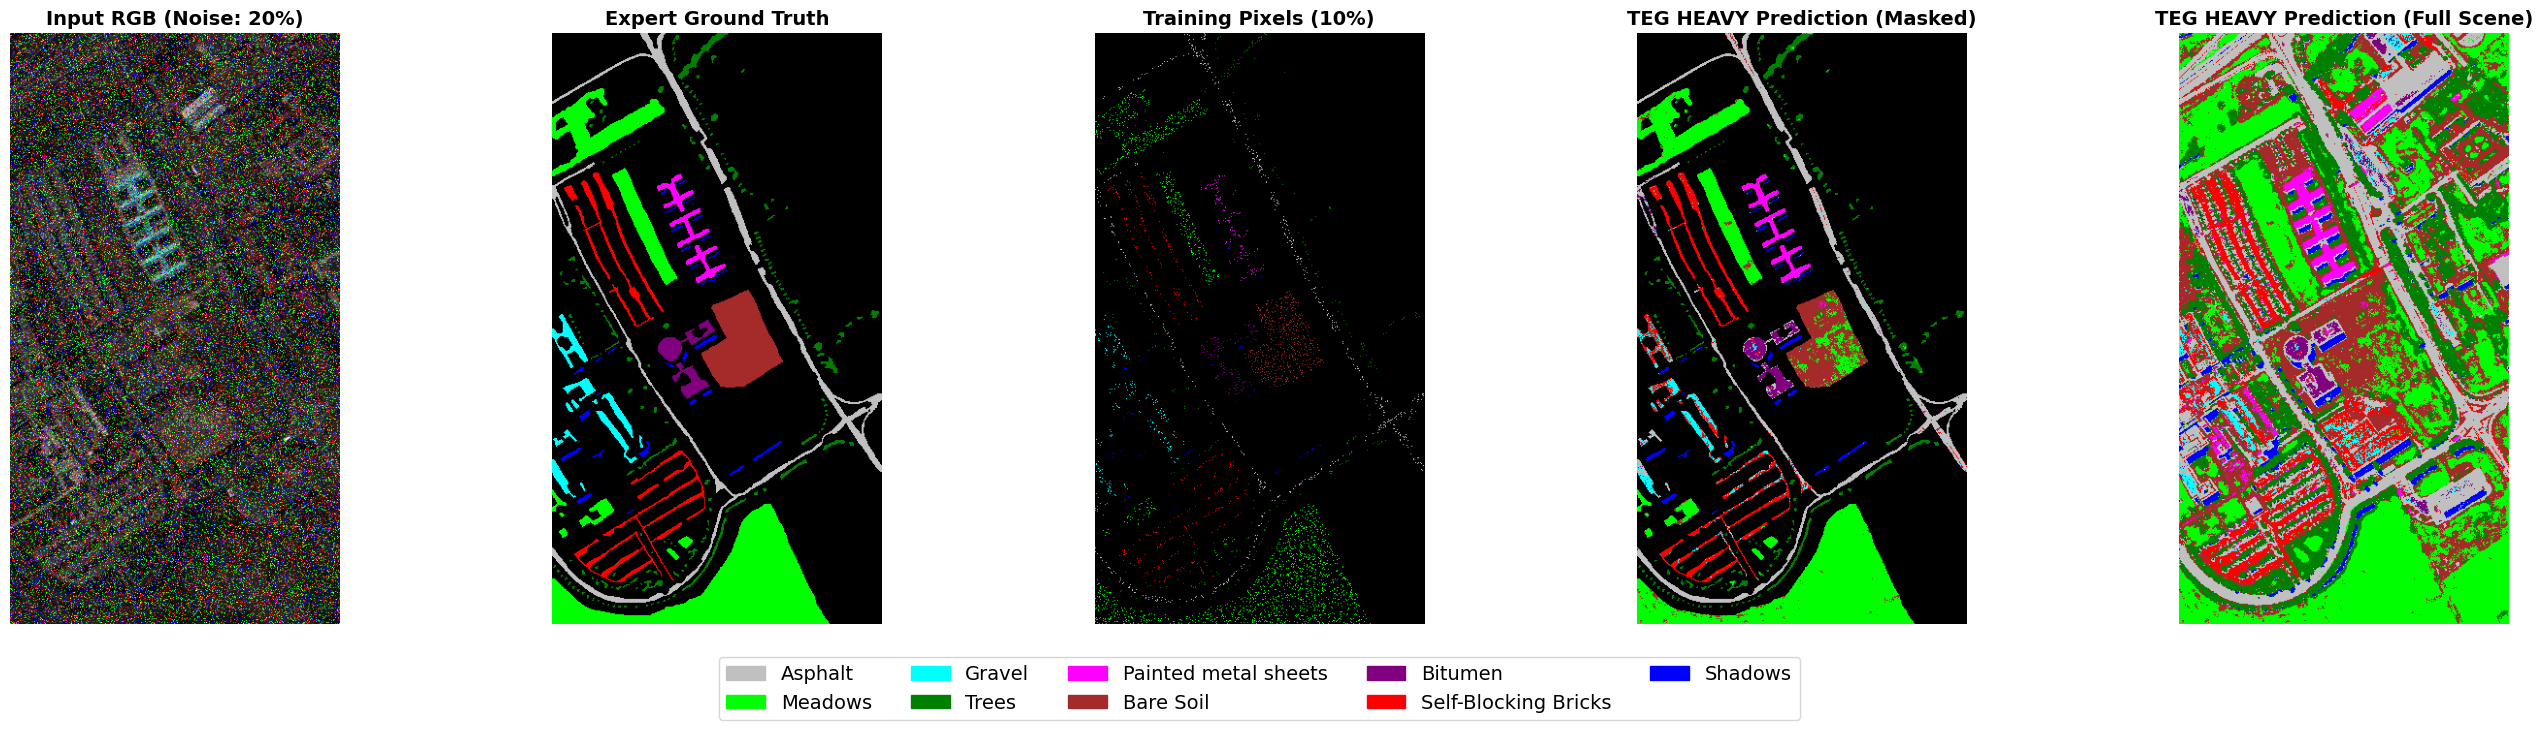

In [43]:
# =============================================================================
# MAIN 5: FULL INFERENCE & CLASSIFICATION MAP (Light & Heavy Modes)
# =============================================================================
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from skimage.feature import local_binary_pattern
from skimage.filters import sobel
from skimage.morphology import disk
from skimage.filters.rank import entropy

warnings.filterwarnings('ignore')

# 1. Official Pavia University color palette (10 classes, where 0 - Background)
pavia_colors = np.array([
    [0, 0, 0],         # 0: Undefined (Black)
    [192, 192, 192],   # 1: Asphalt (Silver/Gray)
    [0, 255, 0],       # 2: Meadows (Light Green)
    [0, 255, 255],     # 3: Gravel (Cyan)
    [0, 128, 0],       # 4: Trees (Dark Green)
    [255, 0, 255],     # 5: Painted metal sheets (Magenta)
    [165, 42, 42],     # 6: Bare Soil (Brown)
    [128, 0, 128],     # 7: Bitumen (Purple)
    [255, 0, 0],       # 8: Self-Blocking Bricks (Red)
    [0, 0, 255]        # 9: Shadows (Blue)
]) / 255.0

pavia_cmap = ListedColormap(pavia_colors)
class_names = ['Undefined', 'Asphalt', 'Meadows', 'Gravel', 'Trees', 
               'Painted metal sheets', 'Bare Soil', 'Bitumen', 
               'Self-Blocking Bricks', 'Shadows']

# 2. Main function for full inference
def run_full_inference(noise_level, train_fraction, mode='light'):
    print(f"[*] 1. Data generation (Noise: {int(noise_level*100)}%, Training: {int(train_fraction*100)}%, Mode: {mode.upper()})...")
    current_cube = data if noise_level == 0 else add_sp_noise_cube(data, noise_ratio=noise_level)
    
    h, w, b_orig = current_cube.shape
    valid_indices = np.where(gt != 0)
    y_valid = gt[valid_indices]
    
    print(f"[*] 2. TEG feature extraction for the FULL scene ({h}x{w})...")
    t0 = time.time()
    lbp_configs = [(1, 8), (2, 16), (3, 24)]
    rgb_viz = get_rgb_image(current_cube) # Store for visualization
    
    if mode == 'light':
        # --- LIGHT MODE: RGB + TEG (18 features) ---
        features = [rgb_viz]
        for ch_idx in range(3):
            ch = rgb_viz[:, :, ch_idx]
            features.append(sobel(ch)[:, :, np.newaxis])
            ch_8bit = (ch * 255).astype(np.uint8)
            features.append(entropy(ch_8bit, disk(3))[:, :, np.newaxis])
            for r, p in lbp_configs:
                lbp_map = local_binary_pattern(ch, p, r, method='uniform')
                features.append((lbp_map / (lbp_map.max()+1e-8))[:, :, np.newaxis])
        teg_cube = np.concatenate(features, axis=2)
        
    elif mode == 'heavy':
        # --- HEAVY MODE: All 103 channels + TEG (618 features) ---
        cube_flat = current_cube.reshape(-1, b_orig)
        cube_norm = (cube_flat - cube_flat.min(axis=0)) / (cube_flat.max(axis=0) - cube_flat.min(axis=0) + 1e-8)
        cube_norm = cube_norm.reshape(current_cube.shape)
        
        features = [cube_norm]
        for ch_idx in range(b_orig):
            ch = cube_norm[:, :, ch_idx]
            features.append(sobel(ch)[:, :, np.newaxis])
            ch_8bit = (ch * 255).astype(np.uint8)
            features.append(entropy(ch_8bit, disk(3))[:, :, np.newaxis])
            for r, p in lbp_configs:
                lbp_map = local_binary_pattern(ch, p, r, method='uniform')
                features.append((lbp_map / (lbp_map.max()+1e-8))[:, :, np.newaxis])
        teg_cube = np.concatenate(features, axis=2)
    else:
        raise ValueError("The mode parameter must be 'light' or 'heavy'")
        
    b_new = teg_cube.shape[2]
    print(f"    -> Extraction completed in {time.time() - t0:.1f}s. Generated: {b_new} features/pixel.")
    
    X_all_raw = teg_cube.reshape(h * w, b_new)
    
    # Split into training according to train_fraction
    print(f"[*] 3. Forming the training set ({int(train_fraction*100)}% of labeled data)...")
    if train_fraction < 1.0:
        train_idx, _ = train_test_split(
            np.arange(len(y_valid)), 
            train_size=train_fraction, 
            stratify=y_valid, 
            random_state=42
        )
    else:
        train_idx = np.arange(len(y_valid))
        
    train_mask_2d = np.zeros_like(gt, dtype=bool)
    train_mask_2d[valid_indices[0][train_idx], valid_indices[1][train_idx]] = True
    
    gt_train_viz = np.zeros_like(gt)
    gt_train_viz[train_mask_2d] = gt[train_mask_2d]
    
    X_train_raw = X_all_raw[train_mask_2d.flatten()]
    y_train = gt.flatten()[train_mask_2d.flatten()] - 1 
    
    print("[*] 4. Normalization and XGBoost training...")
    t0 = time.time()
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_all = scaler.transform(X_all_raw) 
    
    clf = xgb.XGBClassifier(
        objective='multi:softmax', n_estimators=400, max_depth=12, 
        eta=0.3, eval_metric='mlogloss', tree_method='hist', n_jobs=-1, random_state=42
    )
    clf.fit(X_train, y_train)
    print(f"    -> Model training completed in {time.time() - t0:.1f}s.")
    
    print("[*] 5. Class prediction for the entire university scene...")
    t0 = time.time()
    y_pred_all = clf.predict(X_all) + 1 
    prediction_map = y_pred_all.reshape(h, w)
    
    prediction_masked = np.copy(prediction_map)
    prediction_masked[~ (gt != 0)] = 0
    print(f"    -> Inference completed in {time.time() - t0:.1f}s.")
    
    print("[+] Done! Plotting maps...")
    
    # 3. Visualization (5 columns)
    fig, axes = plt.subplots(1, 5, figsize=(28, 7))
    
    axes[0].imshow(rgb_viz)
    axes[0].set_title(f'Input RGB (Noise: {int(noise_level*100)}%)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[1].set_title('Expert Ground Truth', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(gt_train_viz, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[2].set_title(f'Training Pixels ({int(train_fraction*100)}%)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(prediction_masked, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[3].set_title(f'TEG {mode.upper()} Prediction (Masked)', fontsize=14, fontweight='bold')
    axes[3].axis('off')
    
    axes[4].imshow(prediction_map, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[4].set_title(f'TEG {mode.upper()} Prediction (Full Scene)', fontsize=14, fontweight='bold')
    axes[4].axis('off')
    
    patches = [mpatches.Patch(color=pavia_colors[i], label=class_names[i]) for i in range(1, 10)]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=14, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# =============================================================================
# EXPERIMENT LAUNCH (CONTROL INTERFACE)
# =============================================================================
# Adjust these parameters according to your needs:
NOISE_LEVEL    = 0.2     # Noise level (e.g., 0.0, 0.05, 0.10, 0.20)
TRAIN_FRACTION = 0.1     # Training data fraction (e.g., 0.05 for 5%)
TEG_MODE       = 'heavy'  # 'light' (18 features, very fast) or 'heavy' (618 features, slower but more accurate)

run_full_inference(noise_level=NOISE_LEVEL, train_fraction=TRAIN_FRACTION, mode=TEG_MODE)

# 3D-CNN
Source: https://github.com/xiachangxue/DeepHyperX
3D CNN (Spectral–Spatial Classification of Hyperspectral Imagery with 3D Convolutional Neural Network, Li et al., Remote Sensing 2017)

In [45]:
# =============================================================================
# PyTorch 3D-CNN BASELINE (Li et al., 2017)
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time
import numpy as np
from sklearn.preprocessing import StandardScaler

import os
# Prevents OpenMP runtime conflicts on macOS during DataLoader multi-threading
os.environ['OMP_NUM_THREADS'] = '1'

# Check for GPU (CUDA/MPS) availability or fallback to CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"[*] Using device for 3D-CNN: {device}")

# -----------------------------------------------------------------------------
# 1. Shallow 3D-CNN Architecture (Li et al.)
# -----------------------------------------------------------------------------
class Li_3D_CNN(nn.Module):
    def __init__(self, in_channels=1, bands=103, num_classes=9, patch_size=5):
        super(Li_3D_CNN, self).__init__()
        # Input tensor format: (Batch_Size, 1, Bands, Patch_H, Patch_W)
        
        # Layer 1: Spectral-Spatial Convolution
        # Kernel: 7 spectral, 3x3 spatial
        self.conv1 = nn.Conv3d(in_channels, 8, kernel_size=(7, 3, 3), stride=1, padding=0)
        self.relu1 = nn.ReLU()
        
        # Layer 2: Spectral-Spatial Convolution
        # Kernel: 5 spectral, 3x3 spatial (reduces spatial dimensions to 1x1)
        self.conv2 = nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=1, padding=0)
        self.relu2 = nn.ReLU()
        
        # Feature map size calculation (for Flatten layer)
        # With Patch=5, after conv1 (3x3 kernel) -> spatial size is 3x3
        # After conv2 (3x3 kernel) -> spatial size is 1x1
        # Spectral dimension: 103 -> 97 (after kernel 7) -> 93 (after kernel 5)
        flatten_features = 16 * (bands - 6 - 4) * 1 * 1 
        
        self.fc1 = nn.Linear(flatten_features, 256)
        self.dropout = nn.Dropout(p=0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1) # Flatten
        x = self.relu1(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# -----------------------------------------------------------------------------
# 2. 3D Patch Extraction Mechanism
# -----------------------------------------------------------------------------
def create_3d_patches(cube, gt, patch_size=5):
    """
    Extracts 3D patches (spatial windows) from the hyperspectral cube 
    centered around each labeled pixel.
    cube: (H, W, Bands)
    gt: (H, W)
    """
    print(f"[*] Extracting 3D patches (window size: {patch_size}x{patch_size})...")
    h, w, b = cube.shape
    margin = patch_size // 2
    
    # Normalize the entire cube prior to extraction (Standard Scaling)
    cube_flat = cube.reshape(-1, b)
    cube_norm = StandardScaler().fit_transform(cube_flat).reshape(h, w, b)
    
    # Apply zero-padding to handle image borders safely
    padded_cube = np.pad(cube_norm, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    
    patches = []
    labels = []
    
    # Retrieve coordinates of all valid (labeled) pixels
    valid_coords = np.argwhere(gt != 0)
    
    for y, x in valid_coords:
        # Extract the patch (accounting for padding offset)
        patch = padded_cube[y : y + patch_size, x : x + patch_size, :]
        patches.append(patch)
        labels.append(gt[y, x] - 1) # Classes from 0 to 8
        
    patches = np.array(patches)
    labels = np.array(labels)
    
    # Reshape dimensions for PyTorch: (Batch, Channels, Depth[Bands], Height, Width)
    # Convert from (N, H, W, B) to (N, 1, B, H, W)
    patches = np.transpose(patches, (0, 3, 1, 2))
    patches = np.expand_dims(patches, axis=1)
    
    print(f"[+] Successfully generated {patches.shape[0]} patches. Tensor format: {patches.shape}")
    return patches, labels

[*] Using device for 3D-CNN: mps


## Train and validate

In [46]:
# =============================================================================
# TRAINING AND EVALUATING THE 3D-CNN ON NOISY DATA (5% Noise)
# =============================================================================

# 1. Retrieve the noisy hyperspectral cube from Main 1
target_noise_level = 0.05
noisy_cube_3d = noisy_datasets[target_noise_level]

# 2. Generate 3D patches (Note: this is memory-intensive)
X_patches, y_labels = create_3d_patches(noisy_cube_3d, gt, patch_size=5)

# 3. Train/Test Split (using 10% for training, consistent with previous experiments)
train_fraction = 0.10
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_patches, y_labels, train_size=train_fraction, stratify=y_labels, random_state=42
)

print(f"[*] Training samples: {X_train_np.shape[0]}")
print(f"[*] Testing samples:  {X_test_np.shape[0]}")

# 4. Convert NumPy arrays to PyTorch Tensors
X_train_t = torch.FloatTensor(X_train_np)
y_train_t = torch.LongTensor(y_train_np)
X_test_t = torch.FloatTensor(X_test_np)
y_test_t = torch.LongTensor(y_test_np)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# 5. Model Initialization
model = Li_3D_CNN(in_channels=1, bands=103, num_classes=9, patch_size=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Training Loop
epochs = 30
print("\n--- INITIATING 3D-CNN TRAINING ---")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}")

train_time = time.time() - start_time
print(f"[+] Training completed in {train_time:.2f} seconds.")

# 7. Inference and Evaluation
print("\n--- EVALUATING ON TEST SET ---")
model.eval()
all_preds = []
all_targets = []

inf_start = time.time()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

inf_time = time.time() - inf_start

# 8. Calculate Metrics
# Note: Ensure f1_score and accuracy_score are imported from sklearn.metrics
f1_3dcnn = f1_score(all_targets, all_preds, average='macro')
acc_3dcnn = accuracy_score(all_targets, all_preds)

print(f"Shallow 3D-CNN (Li et al.) Results under {int(target_noise_level*100)}% noise and {int(train_fraction*100)}% training data:")
print(f" > Inference Time:         {inf_time:.4f} seconds")
print(f" > Overall Accuracy (OA):  {acc_3dcnn:.4f}")
print(f" > F1-Macro Score:         {f1_3dcnn:.4f}")

# For comparison, these metrics can be benchmarked against the XGBoost results 
# from Main 3 (where TEG achieved an F1 of ~0.8002 at 10% Train)

[*] Extracting 3D patches (window size: 5x5)...
[+] Successfully generated 42776 patches. Tensor format: (42776, 1, 103, 5, 5)
[*] Training samples: 4277
[*] Testing samples:  38499

--- INITIATING 3D-CNN TRAINING ---
Epoch [1/30] - Loss: 0.8553
Epoch [5/30] - Loss: 0.3710
Epoch [10/30] - Loss: 0.2017
Epoch [15/30] - Loss: 0.0803
Epoch [20/30] - Loss: 0.0365
Epoch [25/30] - Loss: 0.0360
Epoch [30/30] - Loss: 0.0089
[+] Training completed in 43.86 seconds.

--- EVALUATING ON TEST SET ---
Shallow 3D-CNN (Li et al.) Results under 5% noise and 10% training data:
 > Inference Time:         4.4120 seconds
 > Overall Accuracy (OA):  0.8724
 > F1-Macro Score:         0.8551


# Перевірка CNN

In [47]:
# =============================================================================
# MAIN 8: 3D-CNN LEARNING CURVES & BENCHMARKING (UPDATED WITH MPS AND LOGS)
# =============================================================================
"""
Module Description:
This script performs a rigorous benchmarking evaluation of a Shallow 3D-CNN 
(based on the architecture by Li et al., 2017) against the proposed TEG-XGBoost 
pipeline. It focuses on evaluating the model's robustness and learning efficiency 
under varying levels of Salt-and-Pepper impulse noise (0% to 20%).

Key Operations:
1. 3D Patch Extraction: Slices the hyperspectral cube into localized spatial 
   windows (e.g., 5x5) to preserve spectral-spatial context for the CNN.
2. Few-Shot Learning Simulation: Evaluates the model's performance across incrementally 
   increasing training data fractions (from 1% up to 70%) to generate learning curves.
3. Computational Profiling: Records precise training and inference times to validate 
   the computational efficiency claims made in the study.
4. Hardware Optimization: Includes dynamic device initialization to fully support 
   Apple Silicon (MPS), CUDA, and standard CPU environments, while managing memory 
   caching to prevent memory leaks during heavy 3D tensor operations.
"""
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# FIX #1: CORRECT APPLE GPU (MPS) INITIALIZATION
# -----------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"[*] 1. Initializing 3D-CNN experiment. Device: {device}")

# -----------------------------------------------------------------------------
# 1. 3D-CNN ARCHITECTURE AND PATCH GENERATOR
# -----------------------------------------------------------------------------
class Li_3D_CNN(nn.Module):
    def __init__(self, in_channels=1, bands=103, num_classes=9, patch_size=5):
        super(Li_3D_CNN, self).__init__()
        self.conv1 = nn.Conv3d(in_channels, 8, kernel_size=(7, 3, 3), stride=1, padding=0)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv3d(8, 16, kernel_size=(5, 3, 3), stride=1, padding=0)
        self.relu2 = nn.ReLU()
        
        flatten_features = 16 * (bands - 6 - 4) * 1 * 1 
        self.fc1 = nn.Linear(flatten_features, 256)
        self.dropout = nn.Dropout(p=0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu1(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def create_3d_patches(cube, gt_mask, patch_size=5):
    h, w, b = cube.shape
    margin = patch_size // 2
    
    cube_flat = cube.reshape(-1, b)
    cube_norm = StandardScaler().fit_transform(cube_flat).reshape(h, w, b)
    padded_cube = np.pad(cube_norm, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    
    patches, labels = [], []
    valid_coords = np.argwhere(gt_mask != 0)
    
    for y, x in valid_coords:
        patch = padded_cube[y : y + patch_size, x : x + patch_size, :]
        patches.append(patch)
        labels.append(gt_mask[y, x] - 1)
        
    patches = np.array(patches)
    labels = np.array(labels)
    
    patches = np.transpose(patches, (0, 3, 1, 2))
    patches = np.expand_dims(patches, axis=1)
    
    return patches, labels

# -----------------------------------------------------------------------------
# 2. UPDATED FUNCTION (WITH PROGRESS LOGS AND MEMORY CLEARING)
# -----------------------------------------------------------------------------
def evaluate_cnn_learning_curve(X_all, y_all, train_fractions, epochs=30, batch_size=64):
    X_train_pool, X_test_np, y_train_pool, y_test_np = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
    )
    
    X_test_t = torch.FloatTensor(X_test_np)
    y_test_t = torch.LongTensor(y_test_np)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)
    
    f1_scores, acc_scores, train_times = [], [], []
    
    for frac in train_fractions:
        n_samples = min(int(len(y_all) * frac), len(y_train_pool))
        
        # FIX #2: Output progress to console
        print(f"        -> Training on {int(frac*100)}% of data ({n_samples} samples)...", end=" ")
        
        if n_samples < len(y_train_pool):
            X_tr_np, _, y_tr_np, _ = train_test_split(
                X_train_pool, y_train_pool, train_size=n_samples, stratify=y_train_pool, random_state=42
            )
        else:
            X_tr_np, y_tr_np = X_train_pool, y_train_pool
            
        train_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_tr_np), torch.LongTensor(y_tr_np)),
            batch_size=batch_size, shuffle=True
        )
        
        model = Li_3D_CNN(in_channels=1, bands=103, num_classes=9, patch_size=5).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        t_start = time.time()
        model.train()
        for ep in range(epochs):
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                optimizer.zero_grad()
                loss = criterion(model(inputs), targets)
                loss.backward()
                optimizer.step()
                
        iter_time = time.time() - t_start
        train_times.append(iter_time)
        print(f"Done in {iter_time:.1f}s.") # Show how long this stage took
        
        # Evaluation
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.numpy())
                
        f1_scores.append(f1_score(all_targets, all_preds, average='macro'))
        acc_scores.append(accuracy_score(all_targets, all_preds))
        
        # Clear GPU cache to prevent the Mac from choking at 70%
        if device.type == 'mps':
            torch.mps.empty_cache()
        elif device.type == 'cuda':
            torch.cuda.empty_cache()
            
    return f1_scores, acc_scores, train_times

# -----------------------------------------------------------------------------
# 3. EXPERIMENT SETUP AND EXECUTION
# -----------------------------------------------------------------------------
# datasets_to_evaluate = {
#     0.0: data,
# }
# datasets_to_evaluate = {
#     0.0: data,                # Clean data
#     0.01: noisy_datasets[0.01], # 1% noise
#     0.10: noisy_datasets[0.10], # 10% noise
#     0.20: noisy_datasets[0.20]  # 20% noise
# }

datasets_to_evaluate = {
    0.0: data,                # Clean data
    0.01: noisy_datasets[0.01], # 1% noise
    0.05: noisy_datasets[0.05], # 5% noise
    0.10: noisy_datasets[0.10], # 10% noise
    0.20: noisy_datasets[0.20]  # 20% noise
}

valid_mask = (gt != 0)
train_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 0.70]
#train_fractions = [0.01, 0.05, 0.10]
fraction_labels = [f"{int(f*100)}%" for f in train_fractions]
EPOCHS = 30 

all_results_f1_cnn = {}
all_results_acc_cnn = {}
all_results_time_cnn = {}
all_extraction_times_cnn = {}

start_time_global = time.time()

for noise_level, current_cube in datasets_to_evaluate.items():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean Data)"
    print(f"\n{'='*85}")
    print(f"[*] RUNNING CNN EXPERIMENT: {noise_str}")
    print(f"{'='*85}")
    
    t0 = time.time()
    X_patches, y_labels = create_3d_patches(current_cube, gt, patch_size=5)
    extract_time = time.time() - t0
    all_extraction_times_cnn[noise_level] = extract_time
    print(f"    -> Extraction time for {X_patches.shape[0]} patches: {extract_time:.2f}s")
    
    print(f"\n  [*] Starting learning curve generation for 3D-CNN (Epochs: {EPOCHS})...")
    
    f1_list, acc_list, time_list = evaluate_cnn_learning_curve(
        X_patches, y_labels, train_fractions, epochs=EPOCHS, batch_size=64
    )
    
    # Inference on 20%
    X_tr_np, X_te_np, y_tr_np, y_te_np = train_test_split(
        X_patches, y_labels, test_size=0.2, stratify=y_labels, random_state=42
    )
    model_bench = Li_3D_CNN().to(device)
    model_bench.eval()
    test_loader_bench = DataLoader(TensorDataset(torch.FloatTensor(X_te_np), torch.LongTensor(y_te_np)), batch_size=256)
    
    t_inf_start = time.time()
    with torch.no_grad():
        for inputs, _ in test_loader_bench:
            inputs = inputs.to(device)
            _ = model_bench(inputs)
    infer_time_20pct = time.time() - t_inf_start
    
    train_time_10pct = time_list[2] 
    print(f"\n      Processing: Baseline: 3D-CNN (Li et al.) | Training [10%]: {train_time_10pct:.2f}s, Inference [20%]: {infer_time_20pct:.2f}s")
    
    all_results_f1_cnn[noise_level] = {"Baseline: 3D-CNN (Li et al.)": f1_list}
    all_results_acc_cnn[noise_level] = {"Baseline: 3D-CNN (Li et al.)": acc_list}
    all_results_time_cnn[noise_level] = {"Baseline: 3D-CNN (Li et al.)": time_list}

print(f"\n[+] All neural network experiments completed in {(time.time() - start_time_global)/60:.1f} minutes!")

[*] 1. Initializing 3D-CNN experiment. Device: mps

[*] RUNNING CNN EXPERIMENT: 0% Noise (Clean Data)
    -> Extraction time for 42776 patches: 0.38s

  [*] Starting learning curve generation for 3D-CNN (Epochs: 30)...
        -> Training on 1% of data (427 samples)... Done in 4.4s.
        -> Training on 5% of data (2138 samples)... Done in 21.7s.
        -> Training on 10% of data (4277 samples)... Done in 43.7s.
        -> Training on 20% of data (8555 samples)... Done in 86.1s.
        -> Training on 50% of data (21388 samples)... Done in 216.7s.
        -> Training on 70% of data (29943 samples)... Done in 300.2s.

      Processing: Baseline: 3D-CNN (Li et al.) | Training [10%]: 43.66s, Inference [20%]: 0.92s

[*] RUNNING CNN EXPERIMENT: 1% Noise
    -> Extraction time for 42776 patches: 2.87s

  [*] Starting learning curve generation for 3D-CNN (Epochs: 30)...
        -> Training on 1% of data (427 samples)... Done in 4.3s.
        -> Training on 5% of data (2138 samples)... Done

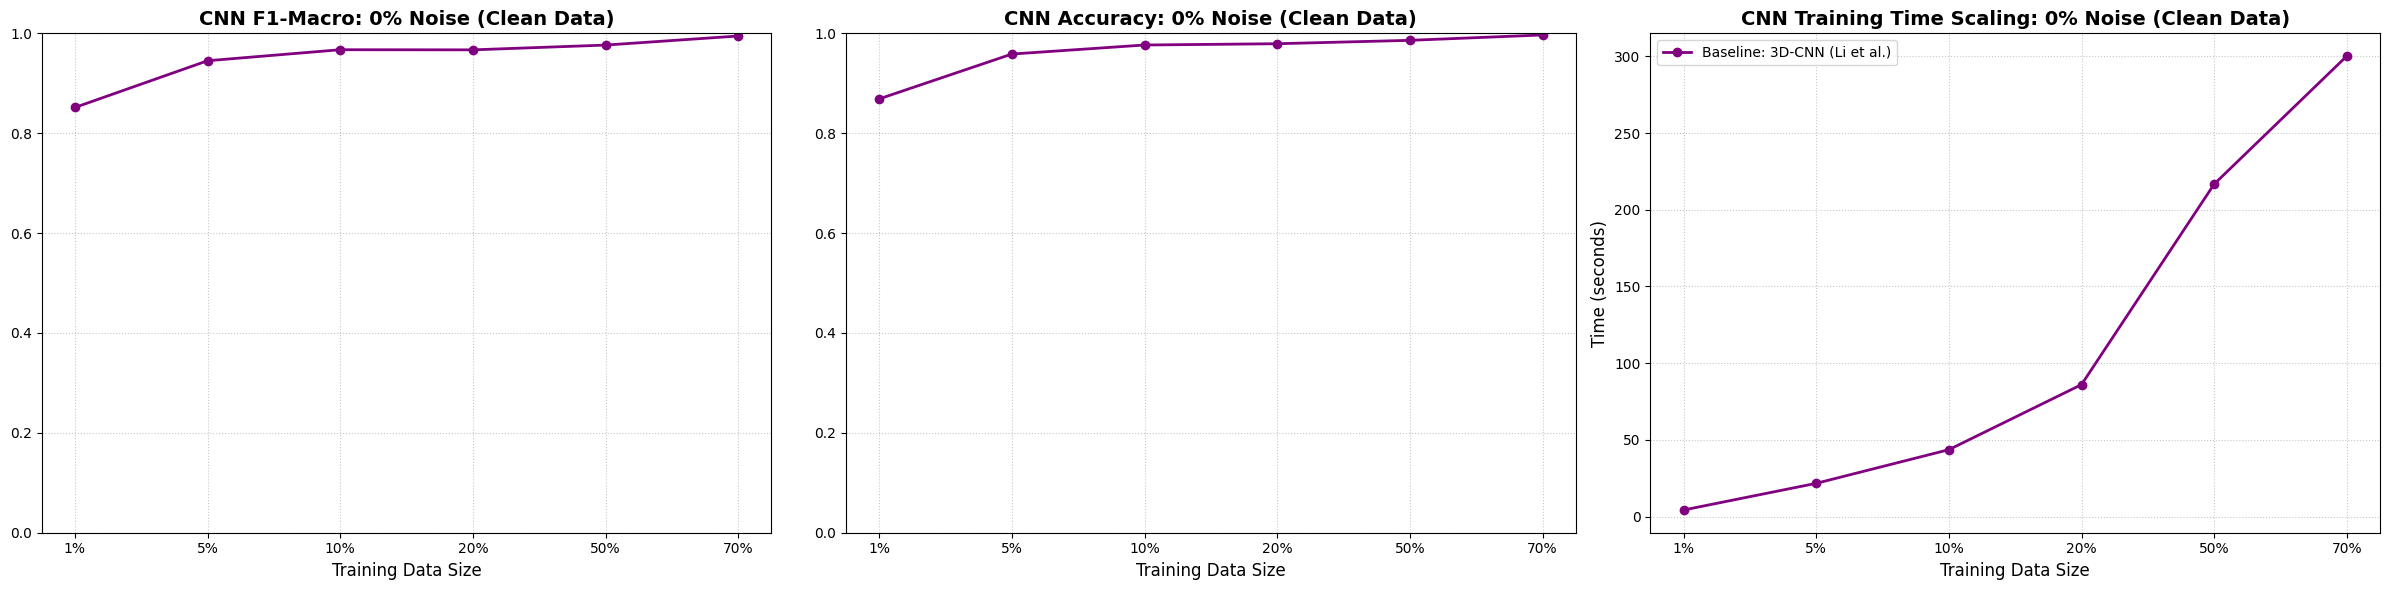


[ 🎯 METRIC: F1-MACRO SCORE - 0% Noise (Clean Data) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.8515,0.9451,0.9672,0.9669,0.9765,0.9946



[ 🎯 METRIC: OVERALL ACCURACY - 0% Noise (Clean Data) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.8687,0.9585,0.9766,0.9792,0.986,0.9967



[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - 0% Noise (Clean Data) ]


,Time (Seconds),Description
Model Architecture,,
Baseline: 3D-CNN (Li et al.),0.379,"103 channels normalization, Zero-padding, 5x5 ..."



[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),4.354,21.746,43.663,86.078,216.72,300.162


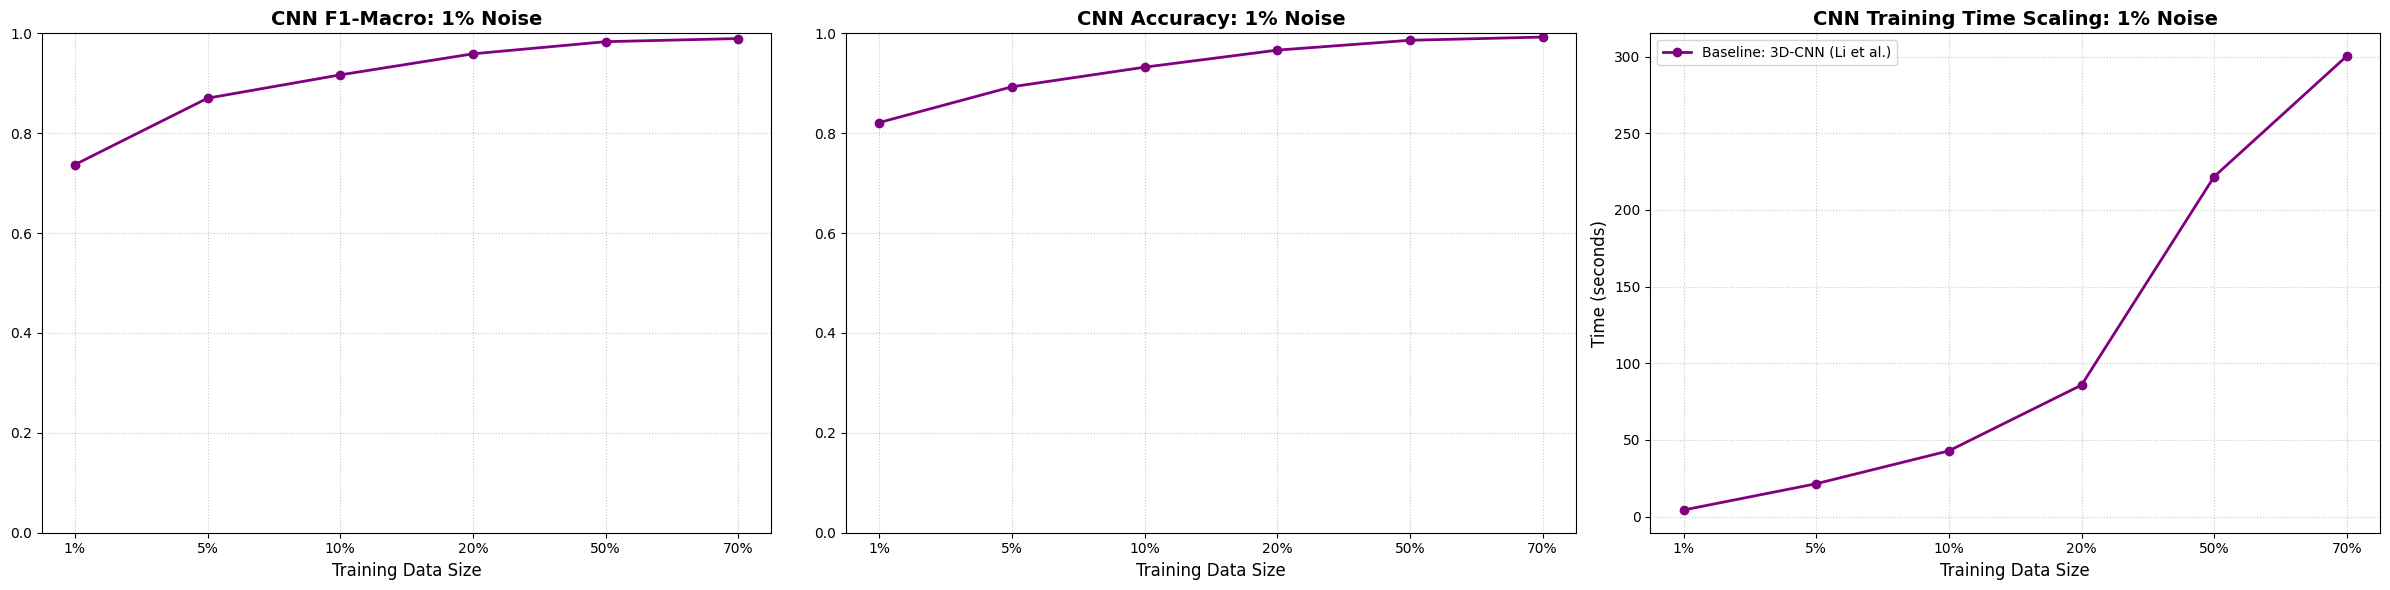


[ 🎯 METRIC: F1-MACRO SCORE - 1% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.7371,0.8701,0.9168,0.959,0.9833,0.9895



[ 🎯 METRIC: OVERALL ACCURACY - 1% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.8213,0.8929,0.9322,0.9663,0.9861,0.9925



[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - 1% Noise ]


,Time (Seconds),Description
Model Architecture,,
Baseline: 3D-CNN (Li et al.),2.871,"103 channels normalization, Zero-padding, 5x5 ..."



[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),4.313,21.461,42.912,85.798,221.769,300.418


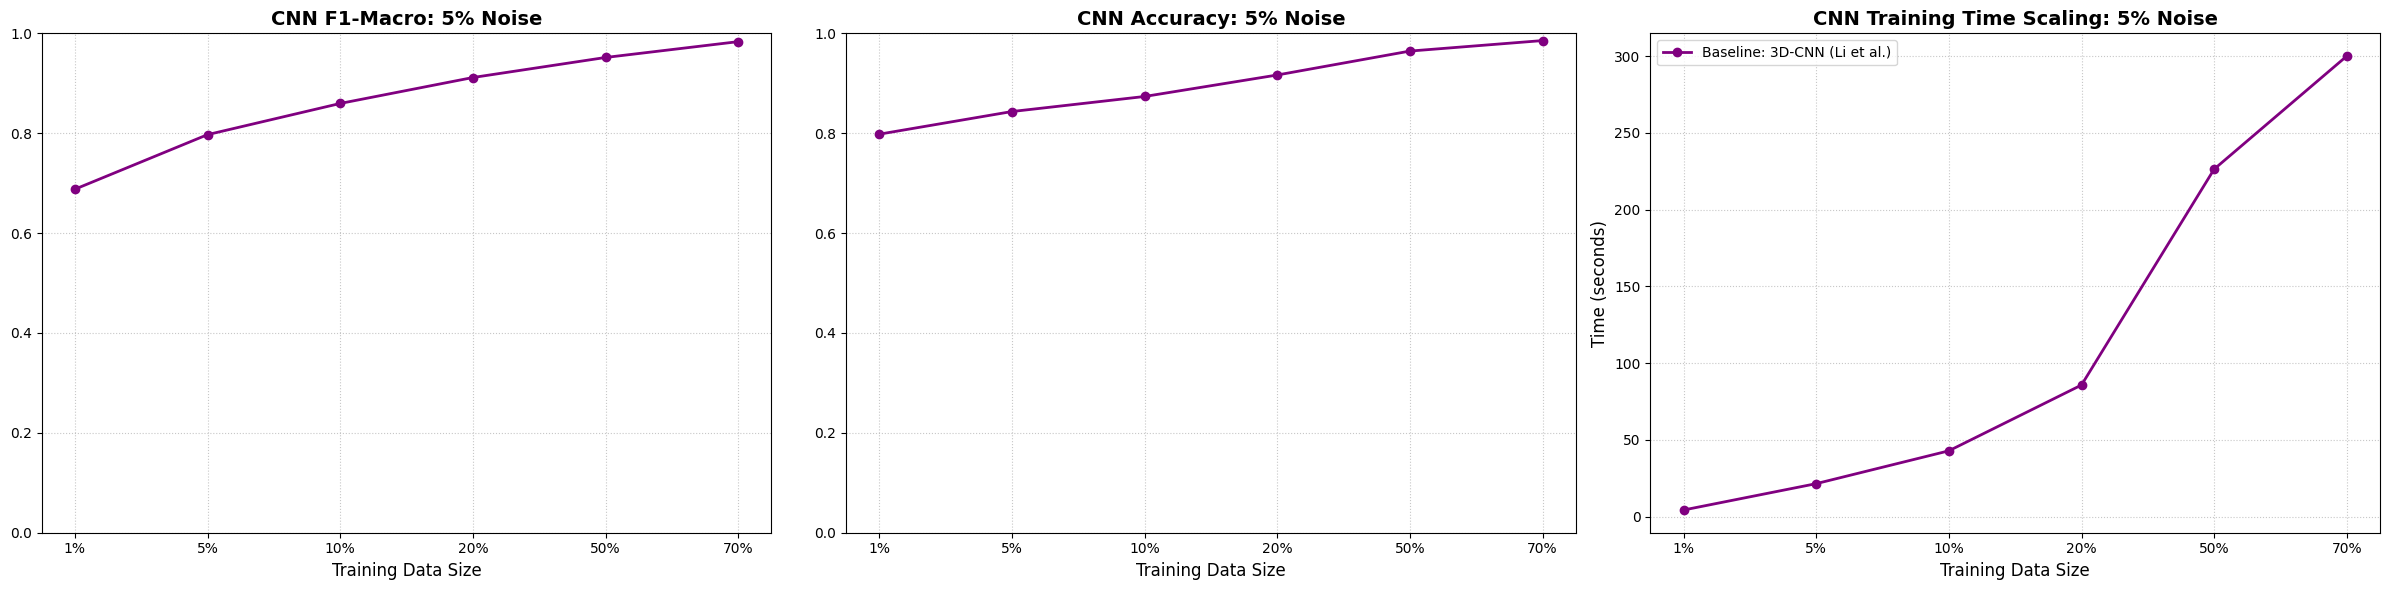


[ 🎯 METRIC: F1-MACRO SCORE - 5% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.6879,0.7971,0.8596,0.9115,0.9517,0.9834



[ 🎯 METRIC: OVERALL ACCURACY - 5% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.798,0.8434,0.8735,0.9165,0.9645,0.9855



[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - 5% Noise ]


,Time (Seconds),Description
Model Architecture,,
Baseline: 3D-CNN (Li et al.),0.483,"103 channels normalization, Zero-padding, 5x5 ..."



[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),4.291,21.472,42.868,85.74,226.419,300.111


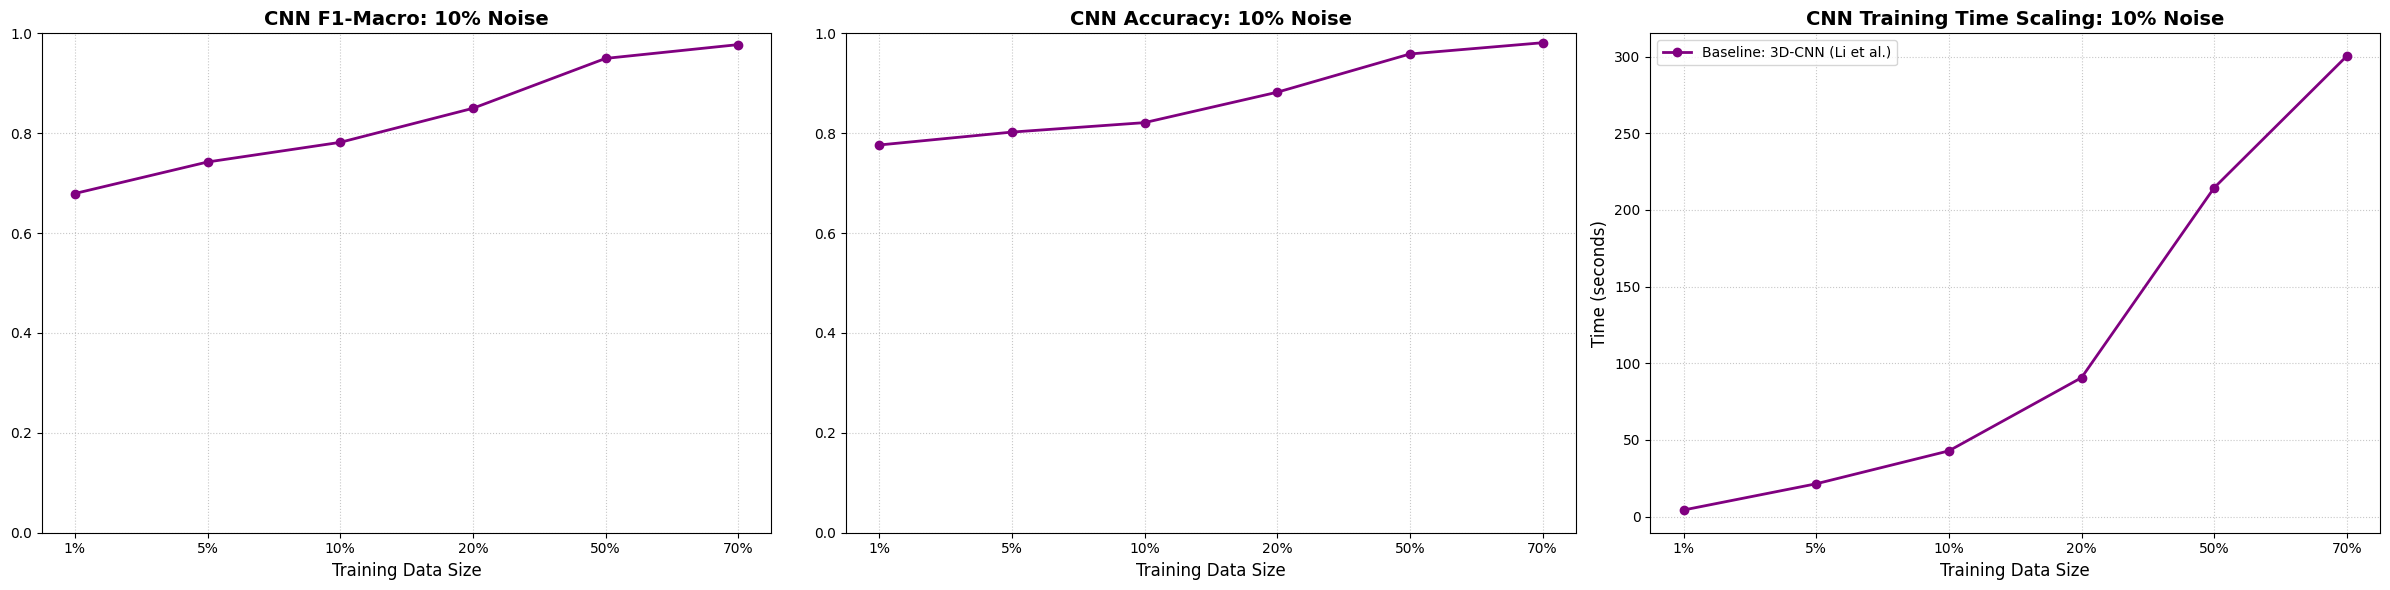


[ 🎯 METRIC: F1-MACRO SCORE - 10% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.6793,0.7424,0.7817,0.8498,0.9498,0.9774



[ 🎯 METRIC: OVERALL ACCURACY - 10% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.7764,0.8022,0.8212,0.8821,0.9586,0.9812



[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - 10% Noise ]


,Time (Seconds),Description
Model Architecture,,
Baseline: 3D-CNN (Li et al.),0.425,"103 channels normalization, Zero-padding, 5x5 ..."



[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),4.347,21.449,42.908,90.616,214.437,300.32


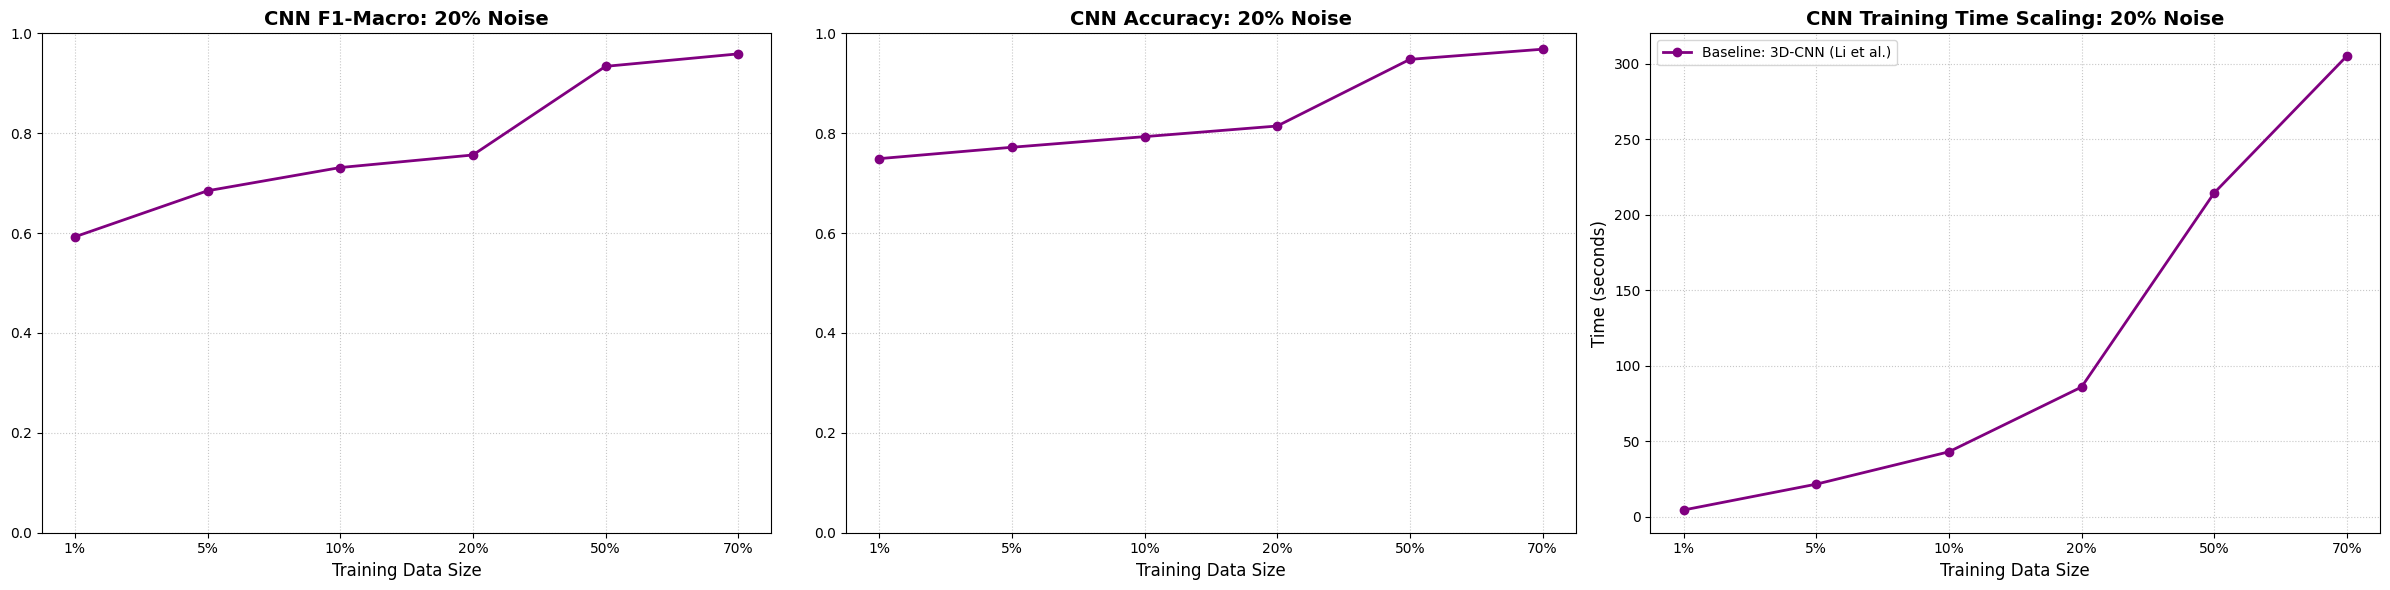


[ 🎯 METRIC: F1-MACRO SCORE - 20% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.5925,0.6847,0.7313,0.7564,0.9339,0.9589



[ 🎯 METRIC: OVERALL ACCURACY - 20% Noise ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),0.7491,0.7719,0.7931,0.8144,0.9479,0.9682



[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - 20% Noise ]


,Time (Seconds),Description
Model Architecture,,
Baseline: 3D-CNN (Li et al.),0.366,"103 channels normalization, Zero-padding, 5x5 ..."



[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]


,1%,5%,10%,20%,50%,70%
Baseline: 3D-CNN (Li et al.),4.301,21.417,42.86,85.75,214.359,305.061


In [48]:
# -----------------------------------------------------------------------------
# 4. VISUALIZATION AND TABLE GENERATION
# -----------------------------------------------------------------------------
styles_cnn = {
    "Baseline: 3D-CNN (Li et al.)": {"color": "purple", "linestyle": "-", "marker": "o"}
}

for noise_level in datasets_to_evaluate.keys():
    noise_str = f"{int(noise_level*100)}% Noise" if noise_level > 0 else "0% Noise (Clean Data)"
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    # Plot 1: F1-Macro Score
    for model_name, scores in all_results_f1_cnn[noise_level].items():
        s = styles_cnn[model_name]
        axes[0].plot(fraction_labels, scores, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[0].set_title(f"CNN F1-Macro: {noise_str}", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Training Data Size", fontsize=12)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, linestyle=':', alpha=0.7)
    
    # Plot 2: Overall Accuracy
    for model_name, scores in all_results_acc_cnn[noise_level].items():
        s = styles_cnn[model_name]
        axes[1].plot(fraction_labels, scores, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[1].set_title(f"CNN Accuracy: {noise_str}", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Training Data Size", fontsize=12)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, linestyle=':', alpha=0.7)
    
    # Plot 3: Training Time
    for model_name, times_array in all_results_time_cnn[noise_level].items():
        s = styles_cnn[model_name]
        axes[2].plot(fraction_labels, times_array, label=model_name, color=s['color'], linestyle=s['linestyle'], marker=s['marker'], linewidth=2)
    axes[2].set_title(f"CNN Training Time Scaling: {noise_str}", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Training Data Size", fontsize=12)
    axes[2].set_ylabel("Time (seconds)", fontsize=12)
    axes[2].grid(True, linestyle=':', alpha=0.7)
    axes[2].legend(loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # DataFrames Generation (Tables)
    df_f1 = pd.DataFrame(all_results_f1_cnn[noise_level], index=fraction_labels).T
    df_acc = pd.DataFrame(all_results_acc_cnn[noise_level], index=fraction_labels).T
    df_train_time = pd.DataFrame(all_results_time_cnn[noise_level], index=fraction_labels).T
    
    print(f"\n[ 🎯 METRIC: F1-MACRO SCORE - {noise_str} ]")
    display(df_f1.round(4))
    
    print(f"\n[ 🎯 METRIC: OVERALL ACCURACY - {noise_str} ]")
    display(df_acc.round(4))
    
    df_static_time = pd.DataFrame({
        "Time (Seconds)": [all_extraction_times_cnn[noise_level]],
        "Description": ["103 channels normalization, Zero-padding, 5x5 3D patch extraction"]
    }, index=["Baseline: 3D-CNN (Li et al.)"])
    df_static_time.index.name = "Model Architecture"
    
    print(f"\n[ ⏳ TABLE 1: DATA PREPARATION TIME (For the entire scene) - {noise_str} ]")
    display(df_static_time.round(3))
    
    print(f"\n[ ⏳ TABLE 2: 3D-CNN TRAINING TIME (By training sample size) ]")
    display(df_train_time.round(3))

[*] Initializing 3D-CNN inference. Device: mps
[*] 1. Data preparation (Noise: 20%, Training: 10%)...
[*] Generating Salt & Pepper noise (Intensity: 20.0%)...
    -> Extracting 3D patches for the full map (207400 pixels)...
    -> All patches generated in 0.8s.
[*] 2. Extracting training set...
[*] 3. Model training (20 epochs)...
    -> Training completed in 28.9s.
[*] 4. Inference for the ENTIRE scene (207,400 pixels)...
    -> Inference completed in 24.4s.
[+] Plotting maps!


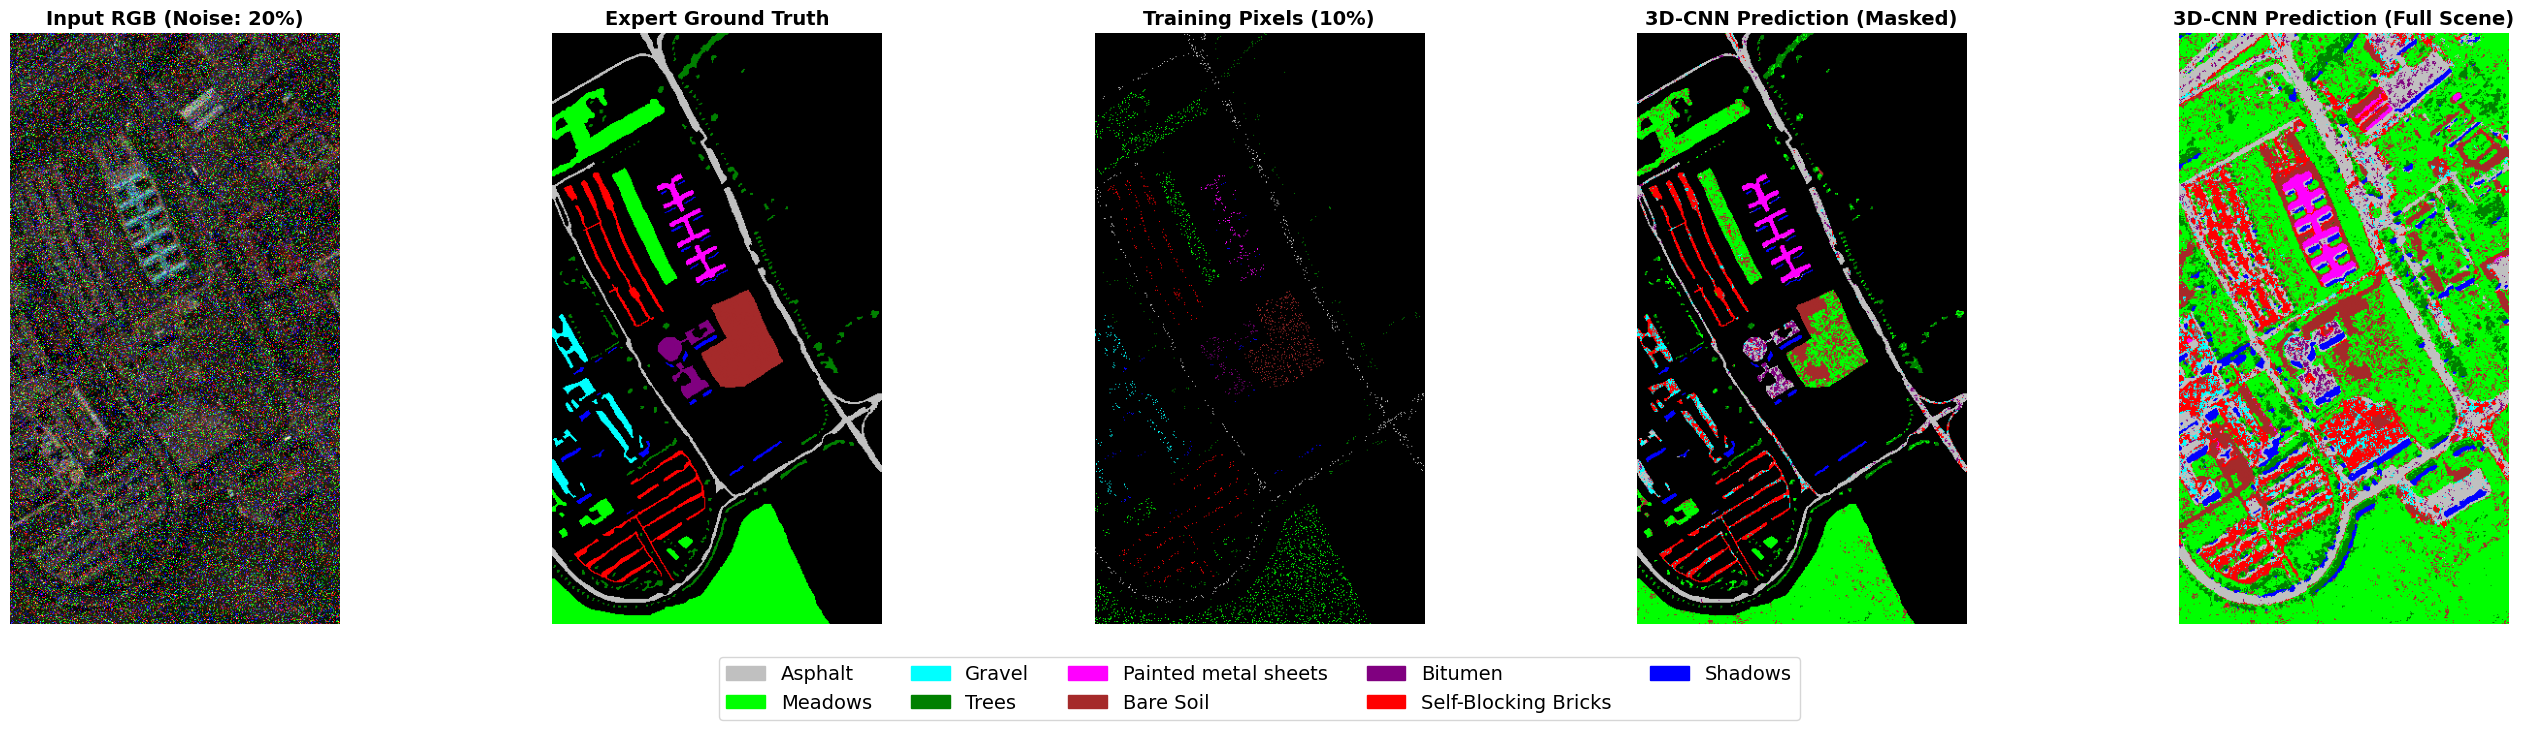

In [50]:
# =============================================================================
# MAIN 9: FULL INFERENCE & CLASSIFICATION MAP FOR 3D-CNN
# =============================================================================
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"[*] Initializing 3D-CNN inference. Device: {device}")

# 1. Official Pavia University color palette
pavia_colors = np.array([
    [0, 0, 0], [192, 192, 192], [0, 255, 0], [0, 255, 255], [0, 128, 0],
    [255, 0, 255], [165, 42, 42], [128, 0, 128], [255, 0, 0], [0, 0, 255]
]) / 255.0

pavia_cmap = ListedColormap(pavia_colors)
class_names = ['Undefined', 'Asphalt', 'Meadows', 'Gravel', 'Trees', 
               'Painted metal sheets', 'Bare Soil', 'Bitumen', 
               'Self-Blocking Bricks', 'Shadows']

# 2. Fast patch generator for the ENTIRE SCENE (207,400 patches)
def create_full_scene_patches(cube, patch_size=5):
    h, w, b = cube.shape
    margin = patch_size // 2
    
    cube_flat = cube.reshape(-1, b)
    cube_norm = StandardScaler().fit_transform(cube_flat).reshape(h, w, b)
    padded = np.pad(cube_norm, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    
    print(f"    -> Extracting 3D patches for the full map ({h*w} pixels)...")
    patches = np.zeros((h * w, patch_size, patch_size, b), dtype=np.float32)
    
    idx = 0
    for y in range(h):
        for x in range(w):
            patches[idx] = padded[y:y+patch_size, x:x+patch_size, :]
            idx += 1
            
    patches = np.transpose(patches, (0, 3, 1, 2)) # (N, B, H, W)
    patches = np.expand_dims(patches, axis=1)     # (N, 1, B, H, W)
    return patches

# 3. Main function
def run_cnn_full_inference(noise_level, train_fraction, epochs=15):
    print(f"[*] 1. Data preparation (Noise: {int(noise_level*100)}%, Training: {int(train_fraction*100)}%)...")
    current_cube = data if noise_level == 0 else add_sp_noise_cube(data, noise_ratio=noise_level)
    rgb_viz = get_rgb_image(current_cube)
    
    h, w, _ = current_cube.shape
    t0 = time.time()
    X_all_patches = create_full_scene_patches(current_cube, patch_size=5)
    print(f"    -> All patches generated in {time.time() - t0:.1f}s.")
    
    print("[*] 2. Extracting training set...")
    valid_indices = np.where(gt != 0)
    valid_flat_indices = valid_indices[0] * w + valid_indices[1] 
    y_valid = gt[valid_indices] - 1
    
    X_valid_patches = X_all_patches[valid_flat_indices]
    
    if train_fraction < 1.0:
        X_tr_np, _, y_tr_np, _ = train_test_split(
            X_valid_patches, y_valid, train_size=train_fraction, stratify=y_valid, random_state=42
        )
        train_idx, _ = train_test_split(np.arange(len(y_valid)), train_size=train_fraction, stratify=y_valid, random_state=42)
    else:
        X_tr_np, y_tr_np = X_valid_patches, y_valid
        train_idx = np.arange(len(y_valid))
        
    train_mask_2d = np.zeros_like(gt, dtype=bool)
    train_mask_2d[valid_indices[0][train_idx], valid_indices[1][train_idx]] = True
    gt_train_viz = np.zeros_like(gt)
    gt_train_viz[train_mask_2d] = gt[train_mask_2d]
    
    print(f"[*] 3. Model training ({epochs} epochs)...")
    train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr_np), torch.LongTensor(y_tr_np)), batch_size=64, shuffle=True)
    
    model = Li_3D_CNN(in_channels=1, bands=103, num_classes=9, patch_size=5).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    t0 = time.time()
    model.train()
    for ep in range(epochs):
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            optimizer.step()
    print(f"    -> Training completed in {time.time() - t0:.1f}s.")
    
    print(f"[*] 4. Inference for the ENTIRE scene (207,400 pixels)...")
    t0 = time.time()
    model.eval()
    all_preds_full = []
    
    # Use a large batch_size to accelerate inference without overflowing GPU memory
    full_scene_loader = DataLoader(TensorDataset(torch.FloatTensor(X_all_patches)), batch_size=1024, shuffle=False)
    
    with torch.no_grad():
        for batch in full_scene_loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds_full.extend(preds.cpu().numpy())
            
    print(f"    -> Inference completed in {time.time() - t0:.1f}s.")
    
    y_pred_all = np.array(all_preds_full) + 1 
    prediction_map = y_pred_all.reshape(h, w)
    
    prediction_masked = np.copy(prediction_map)
    prediction_masked[~ (gt != 0)] = 0
    
    # Clear memory
    if device.type == 'mps': torch.mps.empty_cache()
    
    print("[+] Plotting maps!")
    
    fig, axes = plt.subplots(1, 5, figsize=(28, 7))
    axes[0].imshow(rgb_viz)
    axes[0].set_title(f'Input RGB (Noise: {int(noise_level*100)}%)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[1].set_title('Expert Ground Truth', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(gt_train_viz, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[2].set_title(f'Training Pixels ({int(train_fraction*100)}%)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(prediction_masked, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[3].set_title('3D-CNN Prediction (Masked)', fontsize=14, fontweight='bold')
    axes[3].axis('off')
    
    axes[4].imshow(prediction_map, cmap=pavia_cmap, vmin=0, vmax=9)
    axes[4].set_title('3D-CNN Prediction (Full Scene)', fontsize=14, fontweight='bold')
    axes[4].axis('off')
    
    patches = [mpatches.Patch(color=pavia_colors[i], label=class_names[i]) for i in range(1, 10)]
    fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=14, bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# =============================================================================
# EXPERIMENT LAUNCH (CONTROL INTERFACE)
# =============================================================================
NOISE_LEVEL    = 0.20      # Noise level (e.g., 0.0, 0.05, 0.10, 0.20)
TRAIN_FRACTION = 0.1       # Training data fraction (0.05 for 5%)
EPOCHS         = 20        # Number of epochs (15-20 is sufficient for mapping)

run_cnn_full_inference(noise_level=NOISE_LEVEL, train_fraction=TRAIN_FRACTION, epochs=EPOCHS)